In [1]:
pip install scipy

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


# 1 FDM

### 1.1 FMD code single Layer

Starting implicit FDM solver (Logistic + Apparent Heat Capacity)...
Diagnostics:
  T range       : [-11.926392, 1.000000]
  theta range   : [0.171456, 0.259736]
  dtheta/dT     : [0.005444, 0.007500]
  C_eff range   : [2.058813, 2.280219]
  C_app range   : [3.876987, 4.774665]
  lambda range  : [0.140898, 0.154207]
  dx = 0.050000, dt = 0.024335
  Progress: 10.0%   elapsed: 1.2s
  Progress: 20.0%   elapsed: 2.5s
  Progress: 30.0%   elapsed: 3.6s
  Progress: 40.0%   elapsed: 4.8s
  Progress: 50.0%   elapsed: 6.0s
  Progress: 60.0%   elapsed: 7.2s
  Progress: 70.0%   elapsed: 8.5s
  Progress: 80.0%   elapsed: 11.5s
  Progress: 90.0%   elapsed: 12.6s
Solution completed in 13.7s
Diagnostics:
  T range       : [-11.926392, 2.393861]
  theta range   : [0.171456, 0.270083]
  dtheta/dT     : [0.005444, 0.007500]
  C_eff range   : [2.058813, 2.306167]
  C_app range   : [3.876987, 4.774924]
  lambda range  : [0.139338, 0.154207]
  dx = 0.050000, dt = 0.024335
All-years T min = -12.07999998978022

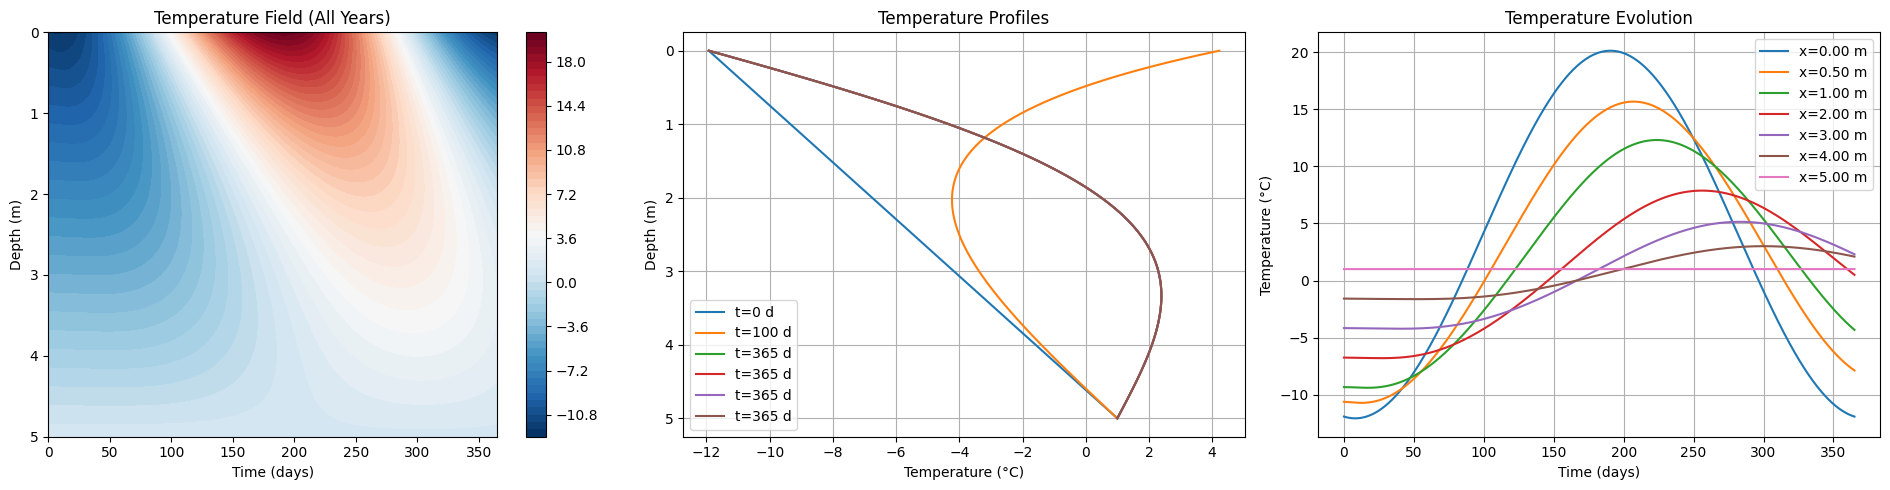

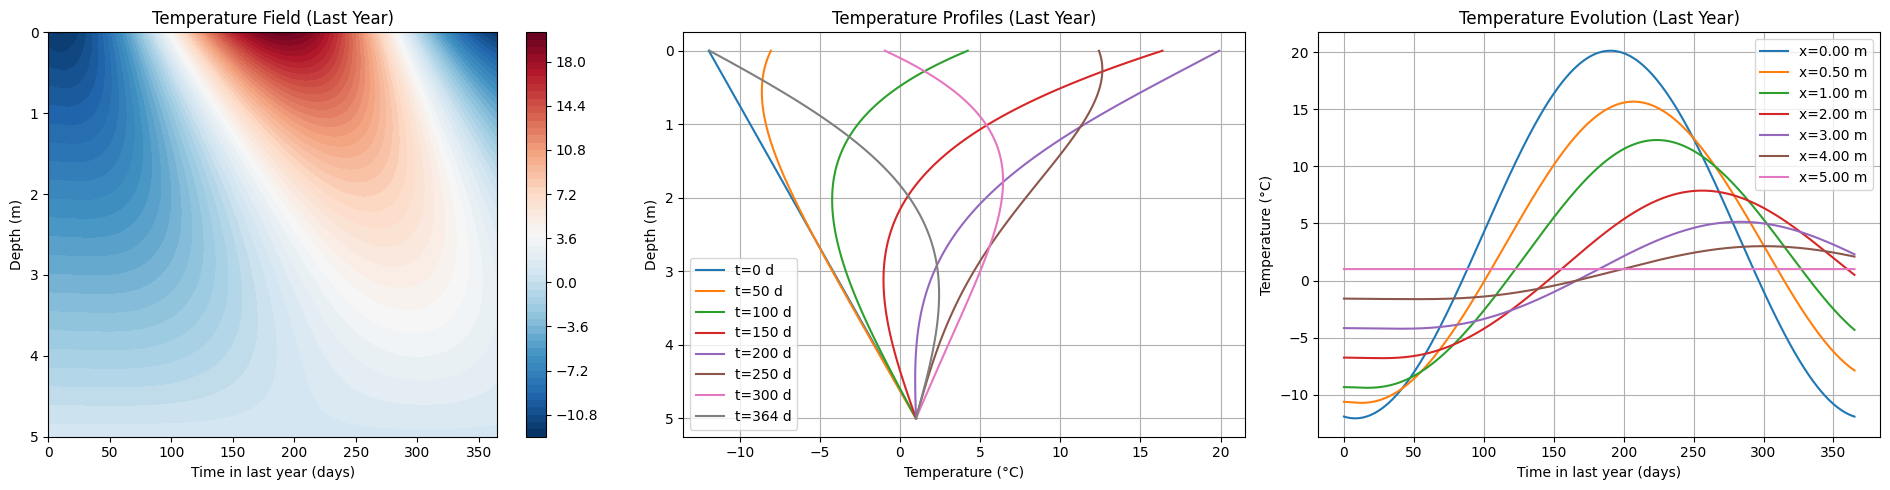

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time


class FreezingSoilFDM_LogisticAHC:
    """
    1D freezing/thawing soil model
    Logistic unfrozen water content + apparent heat capacity (AHC) method
    """

    def __init__(self, params):
        # ---------------------------
        # Physical parameters
        # ---------------------------
        self.L = params['L']                      # latent heat [MJ/m^3]
        self.C_i = params['C_i']                  # ice volumetric heat capacity
        self.C_l = params['C_l']                  # liquid water volumetric heat capacity
        self.C_f = params['C_f']                  # soil skeleton volumetric heat capacity

        self.lambda_i = params['lambda_i']        # ice thermal conductivity [MJ/(day·m·K)]
        self.lambda_l = params['lambda_l']        # liquid water thermal conductivity
        self.lambda_f = params['lambda_f']        # soil skeleton thermal conductivity

        self.eta = params['eta']                  # porosity / max unfrozen water content upper bound
        self.theta_r = params['theta_r']          # residual unfrozen water content
        self.T_f = params['T_f']                  # freezing transition center temperature
        self.k = params['k']                      # logistic steepness

        # ---------------------------
        # Grid parameters
        # ---------------------------
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    # =========================================================
    # Boundary / initial conditions
    # =========================================================
    def boundary_temperature(self, t):
        """
        Surface temperature boundary condition [degC]
        You can modify this function directly if needed.
        """
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        """
        Initial temperature profile [degC]
        Linear profile from surface initial temperature to bottom temperature.
        """
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        """
        Logistic unfrozen water content:
            theta(T) = theta_r + (eta - theta_r)/(1 + exp(-k*(T - T_f)))
        """
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + np.exp(z))

    def dtheta_dT(self, T):
        """
        Derivative of logistic unfrozen water content:
            dtheta/dT = (eta - theta_r) * k * exp(-k*(T-T_f)) / (1+exp(-k*(T-T_f)))^2
        """
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        ez = np.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        """
        Sensible heat capacity only:
            C_eff = (1-eta) C_f + theta C_l + (eta-theta) C_i
        """
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        """
        Apparent heat capacity:
            C_app = C_eff + L * dtheta/dT
        """
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        """
        Effective conductivity:
            lambda_eff = (1-eta) lambda_f + theta lambda_l + (eta-theta) lambda_i
        """
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # =========================================================
    # Initialization
    # =========================================================
    def initialize(self, Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 3):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = self.initial_temperature_profile(self.x)

    # =========================================================
    # Diagnostics
    # =========================================================
    def print_diagnostics(self, T):
        theta = self.theta_unfrozen(T)
        dth = self.dtheta_dT(T)
        Ceff = self.effective_heat_capacity(T)
        Capp = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)

        print("Diagnostics:")
        print(f"  T range       : [{np.min(T):.6f}, {np.max(T):.6f}]")
        print(f"  theta range   : [{np.min(theta):.6f}, {np.max(theta):.6f}]")
        print(f"  dtheta/dT     : [{np.min(dth):.6f}, {np.max(dth):.6f}]")
        print(f"  C_eff range   : [{np.min(Ceff):.6f}, {np.max(Ceff):.6f}]")
        print(f"  C_app range   : [{np.min(Capp):.6f}, {np.max(Capp):.6f}]")
        print(f"  lambda range  : [{np.min(lam):.6f}, {np.max(lam):.6f}]")
        print(f"  dx = {self.dx:.6f}, dt = {self.dt:.6f}")

    # =========================================================
    # Implicit solver
    # =========================================================
    def solve_implicit(self, verbose=True):
        """
        Solve:
            C_app(T) * dT/dt = d/dx( lambda(T) dT/dx )

        Backward-Euler-like implicit discretization with coefficients evaluated at old time step.
        """
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T_old = self.T_field[:, 0].copy()

        if verbose:
            print("Starting implicit FDM solver (Logistic + Apparent Heat Capacity)...")
            self.print_diagnostics(T_old)

        for n in range(1, self.Nt):
            t_new = self.t[n]

            C_app = self.apparent_heat_capacity(T_old)
            lam = self.effective_conductivity(T_old)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # ---------------------------
            # Top boundary: Dirichlet
            # ---------------------------
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_new)

            # ---------------------------
            # Bottom boundary: Dirichlet
            # ---------------------------
            A[-1, -1] = 1.0
            b[-1] = 1.0

            # ---------------------------
            # Interior nodes
            # ---------------------------
            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lam[i], lam[i + 1])
                lam_m = self.harmonic_mean(lam[i], lam[i - 1])

                coef = self.dt / (C_app[i] * self.dx ** 2)

                A[i, i - 1] = -coef * lam_m
                A[i, i] = 1.0 + coef * (lam_p + lam_m)
                A[i, i + 1] = -coef * lam_p

                b[i] = T_old[i]

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T_old = T_new.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Solution completed in {time.time() - start:.1f}s")
            self.print_diagnostics(T_old)

        return self.T_field

    # =========================================================
    # Post-processing
    # =========================================================
    def get_last_year_data(self):
        if self.T_field is None:
            raise RuntimeError("No results available.")
        t_start = self.T_total - 365.0
        mask = self.t >= t_start
        return self.t[mask] - t_start, self.T_field[:, mask]

    def save_results(self, filename="fdm_logistic_ahc_3years.npz"):
        np.savez(
            filename,
            x=self.x,
            t=self.t,
            T_field=self.T_field,
            params={
                'L': self.L,
                'C_i': self.C_i,
                'C_l': self.C_l,
                'C_f': self.C_f,
                'lambda_i': self.lambda_i,
                'lambda_l': self.lambda_l,
                'lambda_f': self.lambda_f,
                'eta': self.eta,
                'theta_r': self.theta_r,
                'T_f': self.T_f,
                'k': self.k
            }
        )
        print(f"Results saved to {filename}")

    def save_last_year_results(self, filename="fdm_logistic_ahc_last_year.npz"):
        t_last, T_last = self.get_last_year_data()
        np.savez(
            filename,
            x=self.x,
            t=t_last,
            T_field=T_last
        )
        print(f"Last-year results saved to {filename}")

    # =========================================================
    # Plotting
    # =========================================================
    def plot_results(self):
        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(self.t, self.x, self.T_field, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (All Years)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 100, 365, 730, 900, 1094]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(self.t - tt))
            axes[1].plot(self.T_field[:, idx], self.x, label=f't={self.t[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(self.t, self.T_field[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    def plot_last_year_results(self):
        t_last, T_last = self.get_last_year_data()

        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(t_last, self.x, T_last, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time in last year (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('Temperature Field (Last Year)')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t_last - tt))
            axes[1].plot(T_last[:, idx], self.x, label=f't={t_last[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles (Last Year)')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(t_last, T_last[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time in last year (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution (Last Year)')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()
if __name__ == "__main__":
    params = {
        # latent heat and volumetric heat capacities [MJ/m^3/K or MJ/m^3]
        # volumetric latent heat [MJ/m^3]
        'L': 334.0,
        # volumetric heat capacities [MJ/(m^3·K)]
        'C_i': 1.672,
        'C_l': 4.18,
        'C_f': 1.60,

        # conductivities converted to MJ/(day·m·K)
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2.000e-6 * 8.64e4,

        # logistic unfrozen water parameters
        'eta': 0.40,       # porosity [-]
        'theta_r': 0.1,    # residual unfrozen water content
        'T_f': -0.3,        # transition center [degC]
        'k': 0.1            # transition steepness[1/degC]
    }

    model = FreezingSoilFDM_LogisticAHC(params)

    # 3-year simulation
    model.initialize(Nx=101, Nt=15000, Lx=5.0, T_total=365.0 * 1)

    T_field_fdm = model.solve_implicit(verbose=True)
    x_fdm = model.x
    t_fdm, T_field_fdm = model.get_last_year_data()
    np.savez(
        "fdm_last_year_result.npz",
        x_fdm=x_fdm,
        t_fdm=t_fdm,
        T_field_fdm=T_field_fdm
    )

    print("All-years T min =", np.min(T_field_fdm))
    print("All-years T max =", np.max(T_field_fdm))
    print("Surface final T =", T_field_fdm[0, -1])
    print("Bottom final T =", T_field_fdm[-1, -1])

    # Plot all years
    model.plot_results()

    # Plot last year
    model.plot_last_year_results()

# 3 Layers

Starting implicit FDM solver (Multi-layer Logistic + AHC)...
Diagnostics:
  T range       : [-11.926392, 1.000000]
  theta range   : [0.171456, 0.259736]
  dtheta/dT     : [0.005444, 0.007500]
  C_eff range   : [2.058813, 2.280219]
  C_app range   : [3.876987, 4.774665]
  lambda range  : [0.140898, 0.154207]
  dx = 0.050000, dt = 0.007300
  Progress: 10.0%   elapsed: 3.9s
  Progress: 20.0%   elapsed: 9.6s
  Progress: 30.0%   elapsed: 13.5s
  Progress: 40.0%   elapsed: 19.2s
  Progress: 50.0%   elapsed: 23.1s
  Progress: 60.0%   elapsed: 26.8s
  Progress: 70.0%   elapsed: 32.5s
  Progress: 80.0%   elapsed: 36.6s
  Progress: 90.0%   elapsed: 40.7s
Solution completed in 46.5s
Diagnostics:
  T range       : [-11.926392, 2.394307]
  theta range   : [0.171456, 0.270086]
  dtheta/dT     : [0.005444, 0.007500]
  C_eff range   : [2.058813, 2.306176]
  C_app range   : [3.876987, 4.774924]
  lambda range  : [0.139337, 0.154207]
  dx = 0.050000, dt = 0.007300
Starting implicit FDM solver (Multi-la

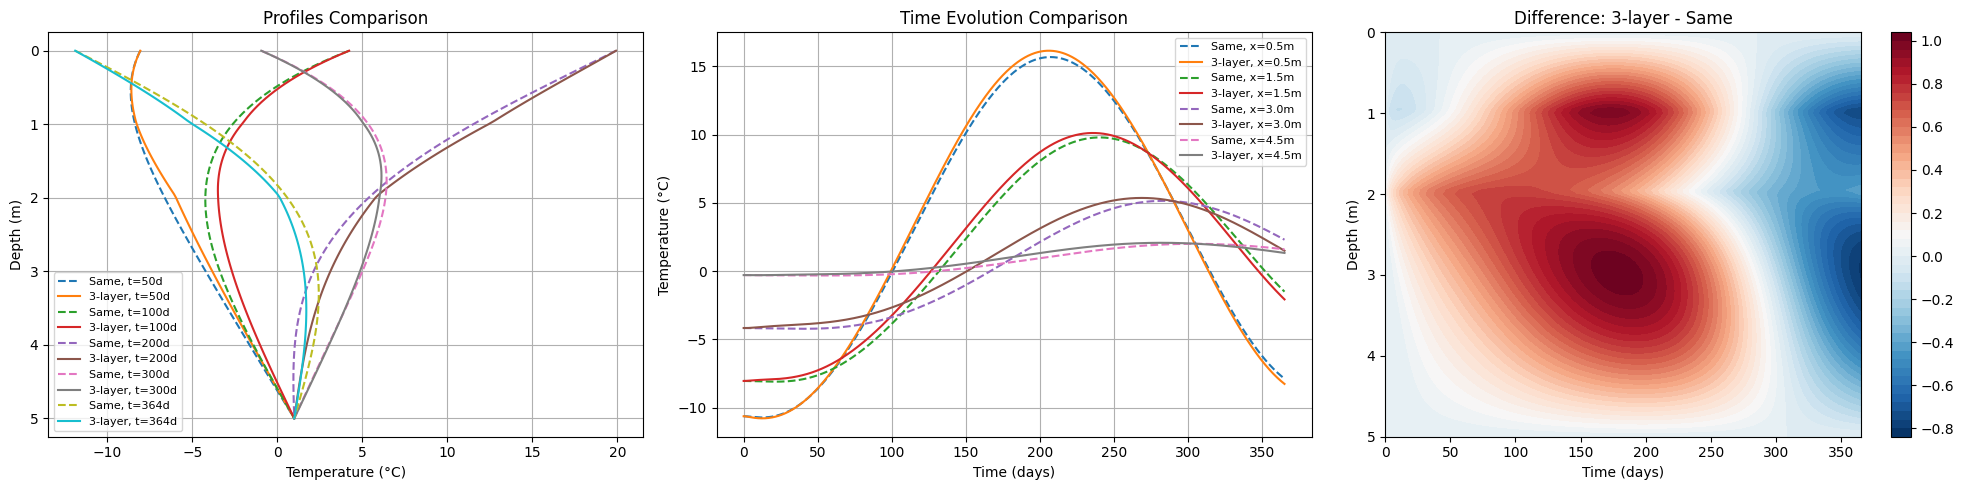

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time


class FreezingSoilFDM_LogisticAHC_MultiLayer:
    """
    1D freezing/thawing soil model
    Logistic unfrozen water + apparent heat capacity (AHC)
    Multi-layer version
    """

    def __init__(self, params, layers):
        # ---------------------------
        # Global physical parameters
        # ---------------------------
        self.L = params['L']                # latent heat [MJ/m^3]
        self.C_i = params['C_i']            # ice volumetric heat capacity
        self.C_l = params['C_l']            # liquid water volumetric heat capacity
        self.lambda_i = params['lambda_i']  # ice thermal conductivity [MJ/(day·m·K)]
        self.lambda_l = params['lambda_l']  # liquid water thermal conductivity

        # ---------------------------
        # Layer definitions
        # Each layer is a dict:
        # {
        #   'z_min': 0.0,
        #   'z_max': 1.0,
        #   'C_f': ...,
        #   'lambda_f': ...,
        #   'eta': ...,
        #   'theta_r': ...,
        #   'T_f': ...,
        #   'k': ...
        # }
        # ---------------------------
        self.layers = layers

        # ---------------------------
        # Grid
        # ---------------------------
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

        # ---------------------------
        # Spatially varying parameter arrays
        # ---------------------------
        self.C_f_arr = None
        self.lambda_f_arr = None
        self.eta_arr = None
        self.theta_r_arr = None
        self.T_f_arr = None
        self.k_arr = None

    # =========================================================
    # Boundary / initial conditions
    # =========================================================
    def boundary_temperature(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    # =========================================================
    # Layer assignment
    # =========================================================
    def build_layered_parameters(self):
        self.C_f_arr = np.zeros_like(self.x)
        self.lambda_f_arr = np.zeros_like(self.x)
        self.eta_arr = np.zeros_like(self.x)
        self.theta_r_arr = np.zeros_like(self.x)
        self.T_f_arr = np.zeros_like(self.x)
        self.k_arr = np.zeros_like(self.x)

        assigned = np.zeros_like(self.x, dtype=bool)

        for layer in self.layers:
            z_min = layer['z_min']
            z_max = layer['z_max']

            # Include right boundary for final layer
            if np.isclose(z_max, self.Lx):
                mask = (self.x >= z_min) & (self.x <= z_max)
            else:
                mask = (self.x >= z_min) & (self.x < z_max)

            self.C_f_arr[mask] = layer['C_f']
            self.lambda_f_arr[mask] = layer['lambda_f']
            self.eta_arr[mask] = layer['eta']
            self.theta_r_arr[mask] = layer['theta_r']
            self.T_f_arr[mask] = layer['T_f']
            self.k_arr[mask] = layer['k']

            assigned[mask] = True

        if not np.all(assigned):
            raise ValueError("Some grid points are not covered by the layer definitions.")

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        z = np.clip(-self.k_arr * (np.asarray(T) - self.T_f_arr), -60.0, 60.0)
        return self.theta_r_arr + (self.eta_arr - self.theta_r_arr) / (1.0 + np.exp(z))

    def dtheta_dT(self, T):
        z = np.clip(-self.k_arr * (np.asarray(T) - self.T_f_arr), -60.0, 60.0)
        ez = np.exp(z)
        return (self.eta_arr - self.theta_r_arr) * self.k_arr * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        theta = self.theta_unfrozen(T)
        return ((1.0 - self.eta_arr) * self.C_f_arr
                + theta * self.C_l
                + (self.eta_arr - theta) * self.C_i)

    def apparent_heat_capacity(self, T):
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        theta = self.theta_unfrozen(T)
        return ((1.0 - self.eta_arr) * self.lambda_f_arr
                + theta * self.lambda_l
                + (self.eta_arr - theta) * self.lambda_i)

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # =========================================================
    # Initialization
    # =========================================================
    def initialize(self, Nx=101, Nt=15000, Lx=5.0, T_total=365.0):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.build_layered_parameters()

        self.T_field = np.zeros((Nx, Nt), dtype=float)
        self.T_field[:, 0] = self.initial_temperature_profile(self.x)

    # =========================================================
    # Diagnostics
    # =========================================================
    def print_diagnostics(self, T):
        theta = self.theta_unfrozen(T)
        dth = self.dtheta_dT(T)
        Ceff = self.effective_heat_capacity(T)
        Capp = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)

        print("Diagnostics:")
        print(f"  T range       : [{np.min(T):.6f}, {np.max(T):.6f}]")
        print(f"  theta range   : [{np.min(theta):.6f}, {np.max(theta):.6f}]")
        print(f"  dtheta/dT     : [{np.min(dth):.6f}, {np.max(dth):.6f}]")
        print(f"  C_eff range   : [{np.min(Ceff):.6f}, {np.max(Ceff):.6f}]")
        print(f"  C_app range   : [{np.min(Capp):.6f}, {np.max(Capp):.6f}]")
        print(f"  lambda range  : [{np.min(lam):.6f}, {np.max(lam):.6f}]")
        print(f"  dx = {self.dx:.6f}, dt = {self.dt:.6f}")

    # =========================================================
    # Implicit solver
    # =========================================================
    def solve_implicit(self, verbose=True):
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        start = time.time()
        T_old = self.T_field[:, 0].copy()

        if verbose:
            print("Starting implicit FDM solver (Multi-layer Logistic + AHC)...")
            self.print_diagnostics(T_old)

        for n in range(1, self.Nt):
            t_new = self.t[n]

            C_app = self.apparent_heat_capacity(T_old)
            lam = self.effective_conductivity(T_old)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # Top boundary
            A[0, 0] = 1.0
            b[0] = self.boundary_temperature(t_new)

            # Bottom boundary
            A[-1, -1] = 1.0
            b[-1] = 1.0

            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lam[i], lam[i + 1])
                lam_m = self.harmonic_mean(lam[i], lam[i - 1])

                coef = self.dt / (C_app[i] * self.dx ** 2)

                A[i, i - 1] = -coef * lam_m
                A[i, i] = 1.0 + coef * (lam_p + lam_m)
                A[i, i + 1] = -coef * lam_p

                b[i] = T_old[i]

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T_old = T_new.copy()

            if verbose and n % max(1, self.Nt // 10) == 0:
                print(f"  Progress: {100.0 * n / self.Nt:.1f}%   elapsed: {time.time() - start:.1f}s")

        if verbose:
            print(f"Solution completed in {time.time() - start:.1f}s")
            self.print_diagnostics(T_old)

        return self.T_field

    # =========================================================
    # Plotting
    # =========================================================
    def plot_results(self, title_suffix=""):
        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(self.t, self.x, self.T_field, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title(f'Temperature Field {title_suffix}')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(self.t - tt))
            axes[1].plot(self.T_field[:, idx], self.x, label=f't={self.t[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title(f'Temperature Profiles {title_suffix}')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(self.x - dd))
            axes[2].plot(self.t, self.T_field[idx, :], label=f'x={self.x[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title(f'Temperature Evolution {title_suffix}')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()


def compare_single_and_three_layer():
    # =====================================================
    # Shared global parameters
    # =====================================================
    global_params = {
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4
    }

    # =====================================================
    # Case 1: single-layer equivalent
    # Actually implemented as 3 layers with identical parameters
    # Should match the original single-layer result very closely
    # =====================================================
    layers_same = [
        {
            'z_min': 0.0, 'z_max': 1.0,
            'C_f': 1.60, 'lambda_f': 2.000e-6 * 8.64e4,
            'eta': 0.40, 'theta_r': 0.10, 'T_f': -0.3, 'k': 0.1
        },
        {
            'z_min': 1.0, 'z_max': 2.0,
            'C_f': 1.60, 'lambda_f': 2.000e-6 * 8.64e4,
            'eta': 0.40, 'theta_r': 0.10, 'T_f': -0.3, 'k': 0.1
        },
        {
            'z_min': 2.0, 'z_max': 5.0,
            'C_f': 1.60, 'lambda_f': 2.000e-6 * 8.64e4,
            'eta': 0.40, 'theta_r': 0.10, 'T_f': -0.3, 'k': 0.1
        }
    ]

    # =====================================================
    # Case 2: true three-layer heterogeneous soil
    # =====================================================
    layers_diff = [
        {
            'z_min': 0.0, 'z_max': 1.0,
            'C_f': 1.60, 'lambda_f': 2.000e-6 * 8.64e4,
            'eta': 0.40, 'theta_r': 0.10, 'T_f': -0.3, 'k': 0.1
        },
        {
            'z_min': 1.0, 'z_max': 2.0,
            'C_f': 2.00, 'lambda_f': 1.500e-6 * 8.64e4,
            'eta': 0.30, 'theta_r': 0.10, 'T_f': -0.3, 'k': 0.1
        },
        {
            'z_min': 2.0, 'z_max': 5.0,
            'C_f': 1.60, 'lambda_f': 2.500e-6 * 8.64e4,
            'eta': 0.30, 'theta_r': 0.10, 'T_f': -0.3, 'k': 0.1
        }
    ]

    # =====================================================
    # Solve same-parameter layered case
    # =====================================================
    model_same = FreezingSoilFDM_LogisticAHC_MultiLayer(global_params, layers_same)
    model_same.initialize(Nx=101, Nt=50000, Lx=5.0, T_total=365.0)
    model_same.solve_implicit(verbose=True)

    # =====================================================
    # Solve different-parameter layered case
    # =====================================================
    model_diff = FreezingSoilFDM_LogisticAHC_MultiLayer(global_params, layers_diff)
    model_diff.initialize(Nx=101, Nt=50000, Lx=5.0, T_total=365.0)
    model_diff.solve_implicit(verbose=True)

    # =====================================================
    # Compare
    # =====================================================
    x = model_same.x
    t = model_same.t
    T_same = model_same.T_field
    T_diff = model_diff.T_field

    error = T_diff - T_same
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))

    print(f"MAE between same-layer and true three-layer = {mae:.6f}")
    print(f"RMSE between same-layer and true three-layer = {rmse:.6f}")

    # -----------------------------------------------------
    # Plot comparison
    # -----------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # 1) temperature at selected times
    times_to_plot = [50, 100, 200, 300, 364]
    for tt in times_to_plot:
        idx = np.argmin(np.abs(t - tt))
        axes[0].plot(T_same[:, idx], x, '--', label=f'Same, t={t[idx]:.0f}d')
        axes[0].plot(T_diff[:, idx], x, '-', label=f'3-layer, t={t[idx]:.0f}d')
    axes[0].invert_yaxis()
    axes[0].set_xlabel("Temperature (°C)")
    axes[0].set_ylabel("Depth (m)")
    axes[0].set_title("Profiles Comparison")
    axes[0].grid(True)
    axes[0].legend(fontsize=8)

    # 2) time history at selected depths
    depths_to_plot = [0.5, 1.5, 3.0, 4.5]
    for dd in depths_to_plot:
        idx = np.argmin(np.abs(x - dd))
        axes[1].plot(t, T_same[idx, :], '--', label=f'Same, x={x[idx]:.1f}m')
        axes[1].plot(t, T_diff[idx, :], '-', label=f'3-layer, x={x[idx]:.1f}m')
    axes[1].set_xlabel("Time (days)")
    axes[1].set_ylabel("Temperature (°C)")
    axes[1].set_title("Time Evolution Comparison")
    axes[1].grid(True)
    axes[1].legend(fontsize=8)

    # 3) error contour
    im = axes[2].contourf(t, x, error, levels=60, cmap='RdBu_r')
    axes[2].invert_yaxis()
    axes[2].set_xlabel("Time (days)")
    axes[2].set_ylabel("Depth (m)")
    axes[2].set_title("Difference: 3-layer - Same")
    plt.colorbar(im, ax=axes[2])

    plt.tight_layout()
    plt.show()

    return model_same, model_diff


if __name__ == "__main__":
    model_same, model_diff = compare_single_and_three_layer()

##  1.3 串联单层法

Lx=5.00 m, progress: 20.0%
Lx=5.00 m, progress: 40.0%
Lx=5.00 m, progress: 60.0%
Lx=5.00 m, progress: 80.0%
Lx=5.00 m finished in 4.48 s
Lx=5.00 m, progress: 20.0%
Lx=5.00 m, progress: 40.0%
Lx=5.00 m, progress: 60.0%
Lx=5.00 m, progress: 80.0%
Lx=5.00 m finished in 2.71 s
Lx=4.00 m, progress: 20.0%
Lx=4.00 m, progress: 40.0%
Lx=4.00 m, progress: 60.0%
Lx=4.00 m, progress: 80.0%
Lx=4.00 m finished in 2.09 s
Lx=3.00 m, progress: 20.0%
Lx=3.00 m, progress: 40.0%
Lx=3.00 m, progress: 60.0%
Lx=3.00 m, progress: 80.0%
Lx=3.00 m finished in 1.83 s

===== Corrected cascade vs pure single =====
MAE      = 0.0000000000
RMSE     = 0.0000000000
Max |err|= 0.0000000000


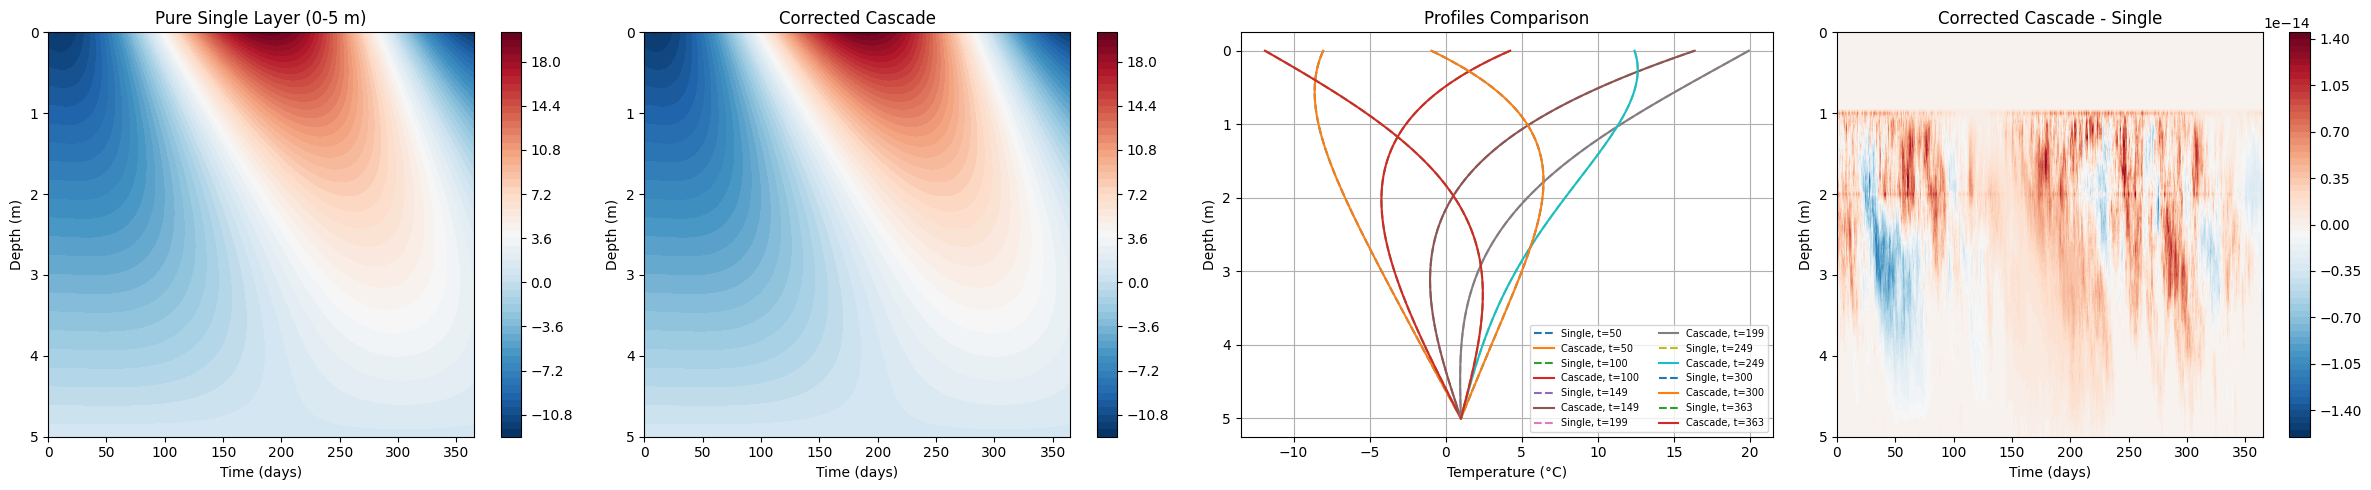

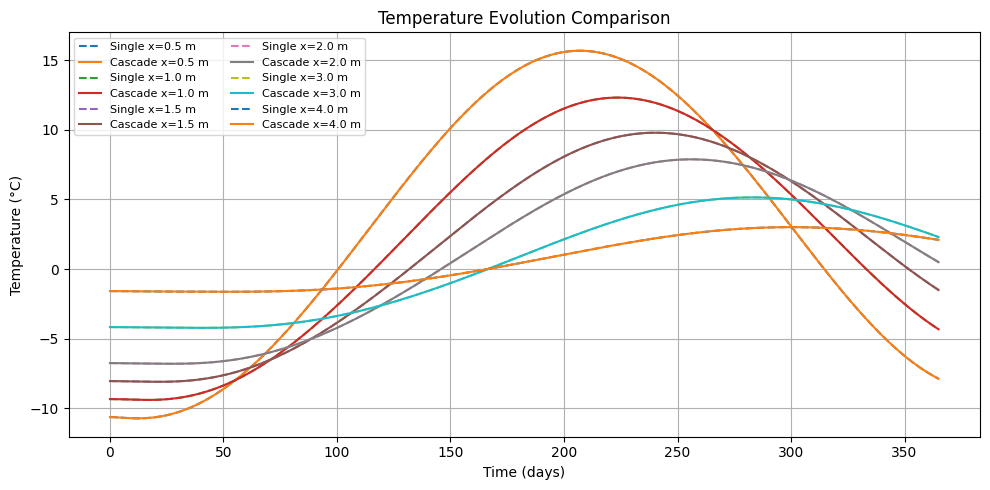

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time


class FreezingSoilFDM_LogisticAHC:
    """
    1D freezing/thawing soil model
    Logistic unfrozen water content + apparent heat capacity (AHC) method
    """

    def __init__(self, params):
        # Physical parameters
        self.L = params['L']
        self.C_i = params['C_i']
        self.C_l = params['C_l']
        self.C_f = params['C_f']

        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']
        self.lambda_f = params['lambda_f']

        self.eta = params['eta']
        self.theta_r = params['theta_r']
        self.T_f = params['T_f']
        self.k = params['k']

        # Grid
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    # =========================================================
    # Boundary / initial conditions
    # =========================================================
    def boundary_temperature(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + np.exp(z))

    def dtheta_dT(self, T):
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        ez = np.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # =========================================================
    # Initialization
    # =========================================================
    def initialize(self, Nx=101, Nt=4000, Lx=5.0, T_total=365.0):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)

    # =========================================================
    # General implicit solver with custom BC + custom initial condition
    # =========================================================
    def solve_implicit_custom_bc(self, top_bc_func, bottom_bc_func, init_profile, verbose=True):
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        self.T_field[:, 0] = init_profile.copy()
        T_old = self.T_field[:, 0].copy()

        start = time.time()

        for n in range(1, self.Nt):
            t_new = self.t[n]

            C_app = self.apparent_heat_capacity(T_old)
            lam = self.effective_conductivity(T_old)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # Top boundary
            A[0, 0] = 1.0
            b[0] = top_bc_func(t_new)

            # Bottom boundary
            A[-1, -1] = 1.0
            b[-1] = bottom_bc_func(t_new)

            # Interior
            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lam[i], lam[i + 1])
                lam_m = self.harmonic_mean(lam[i], lam[i - 1])

                coef = self.dt / (C_app[i] * self.dx ** 2)

                A[i, i - 1] = -coef * lam_m
                A[i, i] = 1.0 + coef * (lam_p + lam_m)
                A[i, i + 1] = -coef * lam_p

                b[i] = T_old[i]

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T_old = T_new.copy()

            if verbose and n % max(1, self.Nt // 5) == 0:
                print(f"Lx={self.Lx:.2f} m, progress: {100.0 * n / self.Nt:.1f}%")

        if verbose:
            print(f"Lx={self.Lx:.2f} m finished in {time.time() - start:.2f} s")

        return self.T_field

    def solve_original_single(self, verbose=True):
        init_profile = self.initial_temperature_profile(self.x)
        return self.solve_implicit_custom_bc(
            top_bc_func=self.boundary_temperature,
            bottom_bc_func=lambda t: 1.0,
            init_profile=init_profile,
            verbose=verbose
        )


def restricted_initial_profile_from_full(x_sub_local, x_offset, full_x, full_T0):
    """
    Build subdomain initial profile by restricting the full-domain initial condition.
    x_sub_local: local coordinate in subdomain, starts from 0
    x_offset: actual starting depth in the original full domain
    """
    x_actual = x_sub_local + x_offset
    return np.interp(x_actual, full_x, full_T0)


def compare_single_vs_cascade_nested():
    # =====================================================
    # Same parameters for all 3 layers
    # =====================================================
    params = {
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,
        'C_f': 1.60,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'lambda_f': 2.000e-6 * 8.64e4,
        'eta': 0.40,
        'theta_r': 0.10,
        'T_f': -0.3,
        'k': 0.1
    }

    Nt = 4000
    T_total = 365.0

    # =====================================================
    # Pure single-layer on 0-5 m
    # =====================================================
    single = FreezingSoilFDM_LogisticAHC(params)
    single.initialize(Nx=101, Nt=Nt, Lx=5.0, T_total=T_total)
    T_single = single.solve_original_single(verbose=True)

    x_full = single.x
    t = single.t
    T0_full = T_single[:, 0].copy()

    # =====================================================
    # Step 1: First-layer-based full simulation on 0-5 m
    # (same as pure single in this equal-parameter test)
    # =====================================================
    step1 = FreezingSoilFDM_LogisticAHC(params)
    step1.initialize(Nx=101, Nt=Nt, Lx=5.0, T_total=T_total)
    T_step1 = step1.solve_original_single(verbose=True)

    # interface at x = 1 m
    idx_1m = np.argmin(np.abs(step1.x - 1.0))
    T12 = T_step1[idx_1m, :]

    # =====================================================
    # Step 2: simulate remaining domain 1-5 m (thickness 4 m)
    # top boundary = T12(t), bottom boundary = 1°C
    # initial condition = restricted full-domain initial condition on 1-5 m
    # =====================================================
    step2 = FreezingSoilFDM_LogisticAHC(params)
    step2.initialize(Nx=81, Nt=Nt, Lx=4.0, T_total=T_total)

    init2 = restricted_initial_profile_from_full(
        x_sub_local=step2.x,
        x_offset=1.0,
        full_x=x_full,
        full_T0=T0_full
    )

    T_step2 = step2.solve_implicit_custom_bc(
        top_bc_func=lambda tt: np.interp(tt, t, T12),
        bottom_bc_func=lambda tt: 1.0,
        init_profile=init2,
        verbose=True
    )

    # interface at actual x = 2 m, local coordinate in step2 is x'=1 m
    idx_local_1m = np.argmin(np.abs(step2.x - 1.0))
    T23 = T_step2[idx_local_1m, :]

    # =====================================================
    # Step 3: simulate remaining domain 2-5 m (thickness 3 m)
    # top boundary = T23(t), bottom boundary = 1°C
    # initial condition = restricted full-domain initial condition on 2-5 m
    # =====================================================
    step3 = FreezingSoilFDM_LogisticAHC(params)
    step3.initialize(Nx=61, Nt=Nt, Lx=3.0, T_total=T_total)

    init3 = restricted_initial_profile_from_full(
        x_sub_local=step3.x,
        x_offset=2.0,
        full_x=x_full,
        full_T0=T0_full
    )

    T_step3 = step3.solve_implicit_custom_bc(
        top_bc_func=lambda tt: np.interp(tt, t, T23),
        bottom_bc_func=lambda tt: 1.0,
        init_profile=init3,
        verbose=True
    )

    # =====================================================
    # Assemble nested-cascade result
    # 0-1 m from step1
    # 1-2 m from step2
    # 2-5 m from step3
    # =====================================================
    T_cascade = np.zeros_like(T_single)

    for i, xx in enumerate(x_full):
        if xx < 1.0:
            idx = np.argmin(np.abs(step1.x - xx))
            T_cascade[i, :] = T_step1[idx, :]
        elif xx < 2.0:
            idx = np.argmin(np.abs(step2.x - (xx - 1.0)))
            T_cascade[i, :] = T_step2[idx, :]
        else:
            idx = np.argmin(np.abs(step3.x - (xx - 2.0)))
            T_cascade[i, :] = T_step3[idx, :]

    # =====================================================
    # Error
    # =====================================================
    error = T_cascade - T_single
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error ** 2))
    max_abs = np.max(np.abs(error))

    print("\n===== Corrected cascade vs pure single =====")
    print(f"MAE      = {mae:.10f}")
    print(f"RMSE     = {rmse:.10f}")
    print(f"Max |err|= {max_abs:.10f}")

    # =====================================================
    # Plot
    # =====================================================
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    im1 = axes[0].contourf(t, x_full, T_single, levels=60, cmap='RdBu_r')
    axes[0].invert_yaxis()
    axes[0].set_title("Pure Single Layer (0-5 m)")
    axes[0].set_xlabel("Time (days)")
    axes[0].set_ylabel("Depth (m)")
    plt.colorbar(im1, ax=axes[0])

    im2 = axes[1].contourf(t, x_full, T_cascade, levels=60, cmap='RdBu_r')
    axes[1].invert_yaxis()
    axes[1].set_title("Corrected Cascade")
    axes[1].set_xlabel("Time (days)")
    axes[1].set_ylabel("Depth (m)")
    plt.colorbar(im2, ax=axes[1])

    times_to_plot = [50, 100, 150, 200, 250, 300, 364]
    for tt in times_to_plot:
        idx_t = np.argmin(np.abs(t - tt))
        axes[2].plot(T_single[:, idx_t], x_full, '--', label=f"Single, t={int(t[idx_t])}")
        axes[2].plot(T_cascade[:, idx_t], x_full, '-', label=f"Cascade, t={int(t[idx_t])}")
    axes[2].invert_yaxis()
    axes[2].set_title("Profiles Comparison")
    axes[2].set_xlabel("Temperature (°C)")
    axes[2].set_ylabel("Depth (m)")
    axes[2].grid(True)
    axes[2].legend(fontsize=7, ncol=2)

    im4 = axes[3].contourf(t, x_full, error, levels=60, cmap='RdBu_r')
    axes[3].invert_yaxis()
    axes[3].set_title("Corrected Cascade - Single")
    axes[3].set_xlabel("Time (days)")
    axes[3].set_ylabel("Depth (m)")
    plt.colorbar(im4, ax=axes[3])

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    depths_to_plot = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
    for dd in depths_to_plot:
        idx = np.argmin(np.abs(x_full - dd))
        plt.plot(t, T_single[idx, :], '--', label=f"Single x={x_full[idx]:.1f} m")
        plt.plot(t, T_cascade[idx, :], '-', label=f"Cascade x={x_full[idx]:.1f} m")
    plt.xlabel("Time (days)")
    plt.ylabel("Temperature (°C)")
    plt.title("Temperature Evolution Comparison")
    plt.grid(True)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    return {
        "single": single,
        "step1": step1,
        "step2": step2,
        "step3": step3,
        "T_cascade": T_cascade,
        "error": error,
        "mae": mae,
        "rmse": rmse,
        "max_abs": max_abs
    }


if __name__ == "__main__":
    results = compare_single_vs_cascade_nested()

## 1.4 三层不同的设置

Lx=5.00 m, progress: 20.0%
Lx=5.00 m, progress: 40.0%
Lx=5.00 m, progress: 60.0%
Lx=5.00 m, progress: 80.0%
Lx=5.00 m finished in 4.84 s
Lx=5.00 m, progress: 20.0%
Lx=5.00 m, progress: 40.0%
Lx=5.00 m, progress: 60.0%
Lx=5.00 m, progress: 80.0%
Lx=5.00 m finished in 3.16 s
Lx=4.00 m, progress: 20.0%
Lx=4.00 m, progress: 40.0%
Lx=4.00 m, progress: 60.0%
Lx=4.00 m, progress: 80.0%
Lx=4.00 m finished in 2.33 s
Lx=3.00 m, progress: 20.0%
Lx=3.00 m, progress: 40.0%
Lx=3.00 m, progress: 60.0%
Lx=3.00 m, progress: 80.0%
Lx=3.00 m finished in 1.74 s


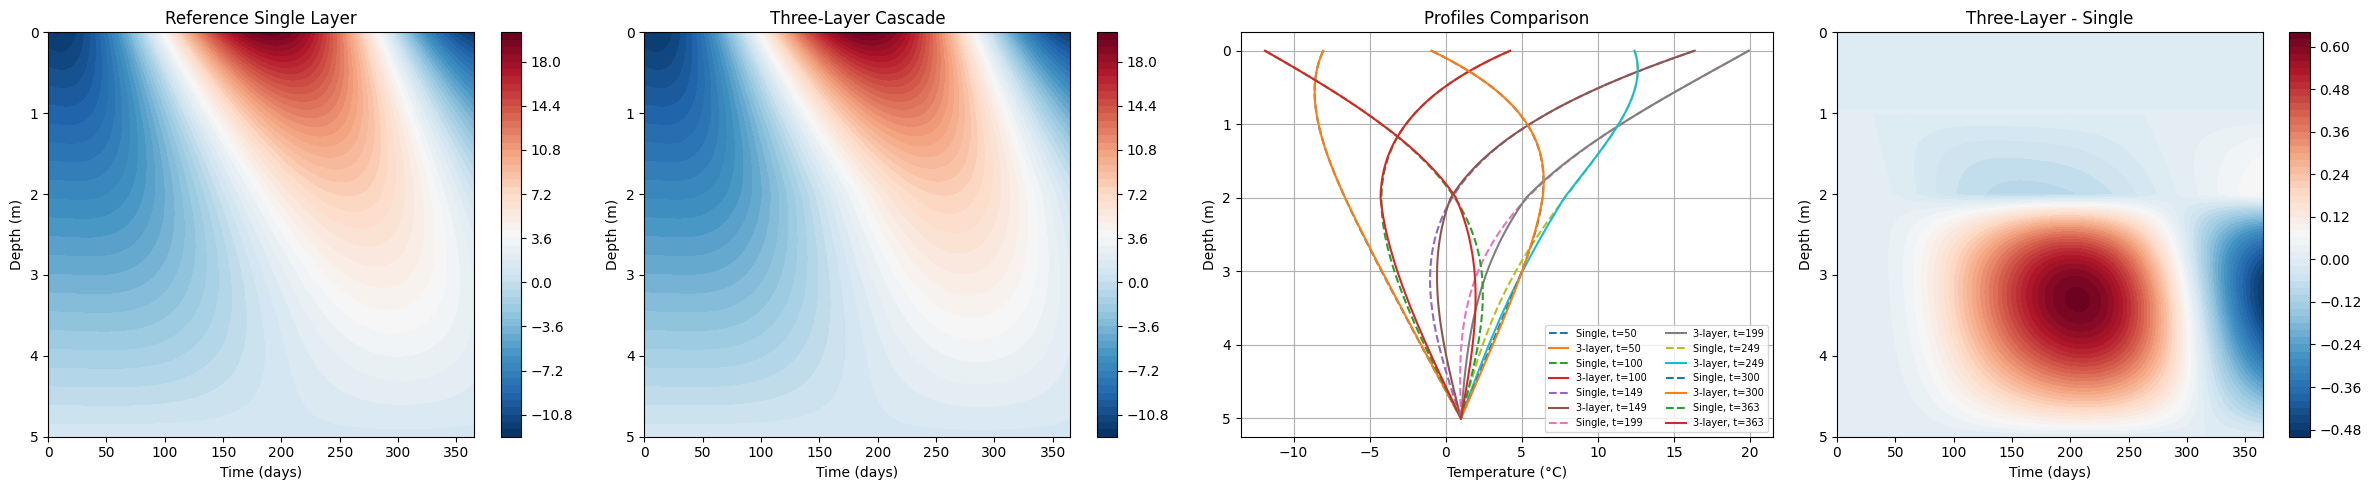

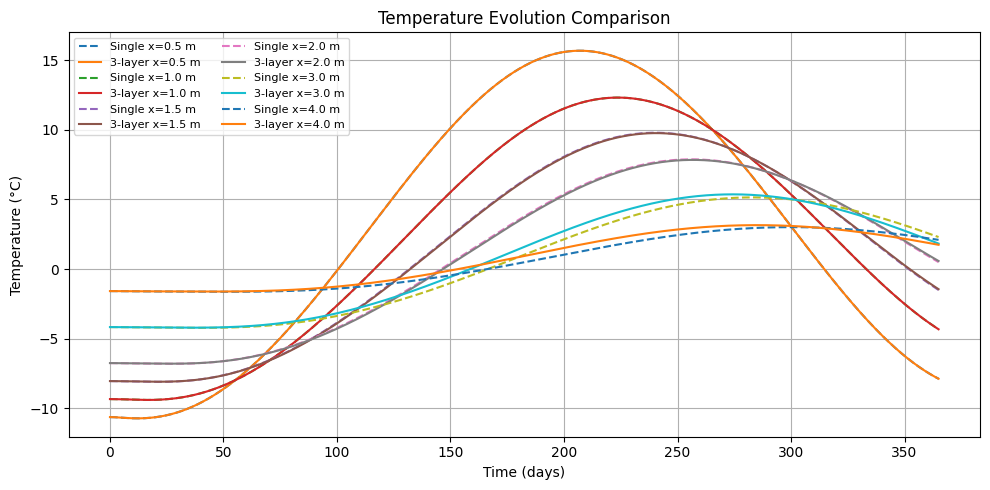

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import time


class FreezingSoilFDM_LogisticAHC:
    """
    1D freezing/thawing soil model
    Logistic unfrozen water content + apparent heat capacity (AHC) method
    """

    def __init__(self, params):
        # Physical parameters
        self.L = params['L']
        self.C_i = params['C_i']
        self.C_l = params['C_l']
        self.C_f = params['C_f']

        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']
        self.lambda_f = params['lambda_f']

        self.eta = params['eta']
        self.theta_r = params['theta_r']
        self.T_f = params['T_f']
        self.k = params['k']

        # Grid
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    # =========================================================
    # Boundary / initial conditions
    # =========================================================
    def boundary_temperature(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + np.exp(z))

    def dtheta_dT(self, T):
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        ez = np.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    # =========================================================
    # Initialization
    # =========================================================
    def initialize(self, Nx=101, Nt=4000, Lx=5.0, T_total=365.0):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)

    # =========================================================
    # General implicit solver with custom BC + custom initial condition
    # =========================================================
    def solve_implicit_custom_bc(self, top_bc_func, bottom_bc_func, init_profile, verbose=True):
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        self.T_field[:, 0] = init_profile.copy()
        T_old = self.T_field[:, 0].copy()

        start = time.time()

        for n in range(1, self.Nt):
            t_new = self.t[n]

            C_app = self.apparent_heat_capacity(T_old)
            lam = self.effective_conductivity(T_old)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            # Top boundary
            A[0, 0] = 1.0
            b[0] = top_bc_func(t_new)

            # Bottom boundary
            A[-1, -1] = 1.0
            b[-1] = bottom_bc_func(t_new)

            # Interior
            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lam[i], lam[i + 1])
                lam_m = self.harmonic_mean(lam[i], lam[i - 1])

                coef = self.dt / (C_app[i] * self.dx ** 2)

                A[i, i - 1] = -coef * lam_m
                A[i, i] = 1.0 + coef * (lam_p + lam_m)
                A[i, i + 1] = -coef * lam_p

                b[i] = T_old[i]

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T_old = T_new.copy()

            if verbose and n % max(1, self.Nt // 5) == 0:
                print(f"Lx={self.Lx:.2f} m, progress: {100.0 * n / self.Nt:.1f}%")

        if verbose:
            print(f"Lx={self.Lx:.2f} m finished in {time.time() - start:.2f} s")

        return self.T_field

    def solve_original_single(self, verbose=True):
        init_profile = self.initial_temperature_profile(self.x)
        return self.solve_implicit_custom_bc(
            top_bc_func=self.boundary_temperature,
            bottom_bc_func=lambda t: 1.0,
            init_profile=init_profile,
            verbose=verbose
        )


def restricted_initial_profile_from_full(x_sub_local, x_offset, full_x, full_T0):
    """
    Build subdomain initial profile by restricting the full-domain initial condition.
    x_sub_local: local coordinate in subdomain, starts from 0
    x_offset: actual starting depth in the original full domain
    """
    x_actual = x_sub_local + x_offset
    return np.interp(x_actual, full_x, full_T0)


def compare_single_vs_cascade_three_layers():
    # =====================================================
    # Shared parameters
    # =====================================================
    common = {
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'theta_r': 0.10,
        'T_f': -0.3,
        'k': 0.1
    }

    # =====================================================
    # Layer 1 parameters
    # =====================================================
    params1 = {
        **common,
        'C_f': 1.6,
        'lambda_f': 2.0e-6 * 8.64e4,
        'eta': 0.4,
        'k': 0.1
    }

    # =====================================================
    # Layer 2 parameters
    # =====================================================
    params2 = {
        **common,
        'C_f': 2.0,
        'lambda_f': 1.5e-6 * 8.64e4,
        'eta': 0.3,
        'k': 0.1
    }

    # =====================================================
    # Layer 3 parameters
    # =====================================================
    params3 = {
        **common,
        'C_f': 1.6,
        'lambda_f': 2.5e-6 * 8.64e4,
        'eta': 0.3,
        'k': 0.1
    }

    Nt = 4000
    T_total = 365.0

    # =====================================================
    # Reference pure single-layer case
    # Here I keep it as layer-1 parameters for comparison
    # =====================================================
    single = FreezingSoilFDM_LogisticAHC(params1)
    single.initialize(Nx=101, Nt=Nt, Lx=5.0, T_total=T_total)
    T_single = single.solve_original_single(verbose=True)

    x_full = single.x
    t = single.t
    T0_full = T_single[:, 0].copy()

    # =====================================================
    # Step 1: 0-5 m using layer-1 parameters
    # =====================================================
    step1 = FreezingSoilFDM_LogisticAHC(params1)
    step1.initialize(Nx=101, Nt=Nt, Lx=5.0, T_total=T_total)
    T_step1 = step1.solve_original_single(verbose=True)

    idx_1m = np.argmin(np.abs(step1.x - 1.0))
    T12 = T_step1[idx_1m, :]

    # =====================================================
    # Step 2: 1-5 m using layer-2 parameters
    # top boundary = T12(t)
    # bottom boundary = 1°C
    # =====================================================
    step2 = FreezingSoilFDM_LogisticAHC(params2)
    step2.initialize(Nx=81, Nt=Nt, Lx=4.0, T_total=T_total)

    init2 = restricted_initial_profile_from_full(
        x_sub_local=step2.x,
        x_offset=1.0,
        full_x=x_full,
        full_T0=T0_full
    )

    T_step2 = step2.solve_implicit_custom_bc(
        top_bc_func=lambda tt: np.interp(tt, t, T12),
        bottom_bc_func=lambda tt: 1.0,
        init_profile=init2,
        verbose=True
    )

    idx_local_1m = np.argmin(np.abs(step2.x - 1.0))
    T23 = T_step2[idx_local_1m, :]

    # =====================================================
    # Step 3: 2-5 m using layer-3 parameters
    # top boundary = T23(t)
    # bottom boundary = 1°C
    # =====================================================
    step3 = FreezingSoilFDM_LogisticAHC(params3)
    step3.initialize(Nx=61, Nt=Nt, Lx=3.0, T_total=T_total)

    init3 = restricted_initial_profile_from_full(
        x_sub_local=step3.x,
        x_offset=2.0,
        full_x=x_full,
        full_T0=T0_full
    )

    T_step3 = step3.solve_implicit_custom_bc(
        top_bc_func=lambda tt: np.interp(tt, t, T23),
        bottom_bc_func=lambda tt: 1.0,
        init_profile=init3,
        verbose=True
    )

    # =====================================================
    # Assemble final three-layer cascade result
    # 0-1 m from step1
    # 1-2 m from step2
    # 2-5 m from step3
    # =====================================================
    T_cascade = np.zeros_like(T_single)

    for i, xx in enumerate(x_full):
        if xx < 1.0:
            idx = np.argmin(np.abs(step1.x - xx))
            T_cascade[i, :] = T_step1[idx, :]
        elif xx < 2.0:
            idx = np.argmin(np.abs(step2.x - (xx - 1.0)))
            T_cascade[i, :] = T_step2[idx, :]
        else:
            idx = np.argmin(np.abs(step3.x - (xx - 2.0)))
            T_cascade[i, :] = T_step3[idx, :]

    # =====================================================
    # Plot results
    # =====================================================
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    im1 = axes[0].contourf(t, x_full, T_single, levels=60, cmap='RdBu_r')
    axes[0].invert_yaxis()
    axes[0].set_title("Reference Single Layer")
    axes[0].set_xlabel("Time (days)")
    axes[0].set_ylabel("Depth (m)")
    plt.colorbar(im1, ax=axes[0])

    im2 = axes[1].contourf(t, x_full, T_cascade, levels=60, cmap='RdBu_r')
    axes[1].invert_yaxis()
    axes[1].set_title("Three-Layer Cascade")
    axes[1].set_xlabel("Time (days)")
    axes[1].set_ylabel("Depth (m)")
    plt.colorbar(im2, ax=axes[1])

    times_to_plot = [50, 100, 150, 200, 250, 300, 364]
    for tt in times_to_plot:
        idx_t = np.argmin(np.abs(t - tt))
        axes[2].plot(T_single[:, idx_t], x_full, '--', label=f"Single, t={int(t[idx_t])}")
        axes[2].plot(T_cascade[:, idx_t], x_full, '-', label=f"3-layer, t={int(t[idx_t])}")
    axes[2].invert_yaxis()
    axes[2].set_title("Profiles Comparison")
    axes[2].set_xlabel("Temperature (°C)")
    axes[2].set_ylabel("Depth (m)")
    axes[2].grid(True)
    axes[2].legend(fontsize=7, ncol=2)

    error = T_cascade - T_single
    im4 = axes[3].contourf(t, x_full, error, levels=60, cmap='RdBu_r')
    axes[3].invert_yaxis()
    axes[3].set_title("Three-Layer - Single")
    axes[3].set_xlabel("Time (days)")
    axes[3].set_ylabel("Depth (m)")
    plt.colorbar(im4, ax=axes[3])

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    depths_to_plot = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
    for dd in depths_to_plot:
        idx = np.argmin(np.abs(x_full - dd))
        plt.plot(t, T_single[idx, :], '--', label=f"Single x={x_full[idx]:.1f} m")
        plt.plot(t, T_cascade[idx, :], '-', label=f"3-layer x={x_full[idx]:.1f} m")
    plt.xlabel("Time (days)")
    plt.ylabel("Temperature (°C)")
    plt.title("Temperature Evolution Comparison")
    plt.grid(True)
    plt.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

    return {
        "single": single,
        "step1": step1,
        "step2": step2,
        "step3": step3,
        "T_cascade": T_cascade,
        "T12": T12,
        "T23": T23,
        "error": error
    }


if __name__ == "__main__":
    results = compare_single_vs_cascade_three_layers()

Lx=5.00 m, progress: 20.0%
Lx=5.00 m, progress: 40.0%
Lx=5.00 m, progress: 60.0%
Lx=5.00 m, progress: 80.0%
Lx=5.00 m finished in 2.88 s
Lx=4.00 m, progress: 20.0%
Lx=4.00 m, progress: 40.0%
Lx=4.00 m, progress: 60.0%
Lx=4.00 m, progress: 80.0%
Lx=4.00 m finished in 2.32 s
Lx=3.00 m, progress: 20.0%
Lx=3.00 m, progress: 40.0%
Lx=3.00 m, progress: 60.0%
Lx=3.00 m, progress: 80.0%
Lx=3.00 m finished in 1.81 s


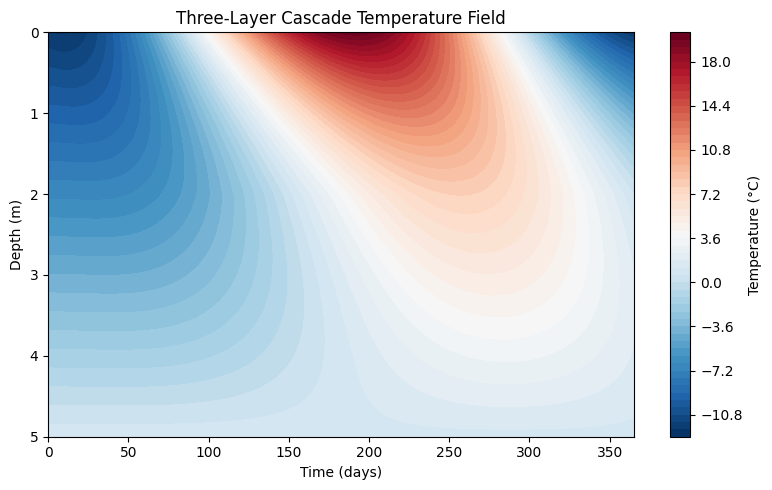

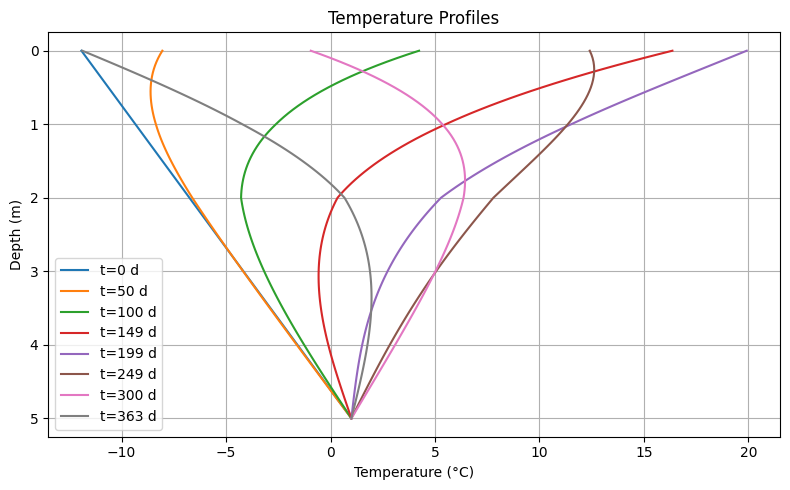

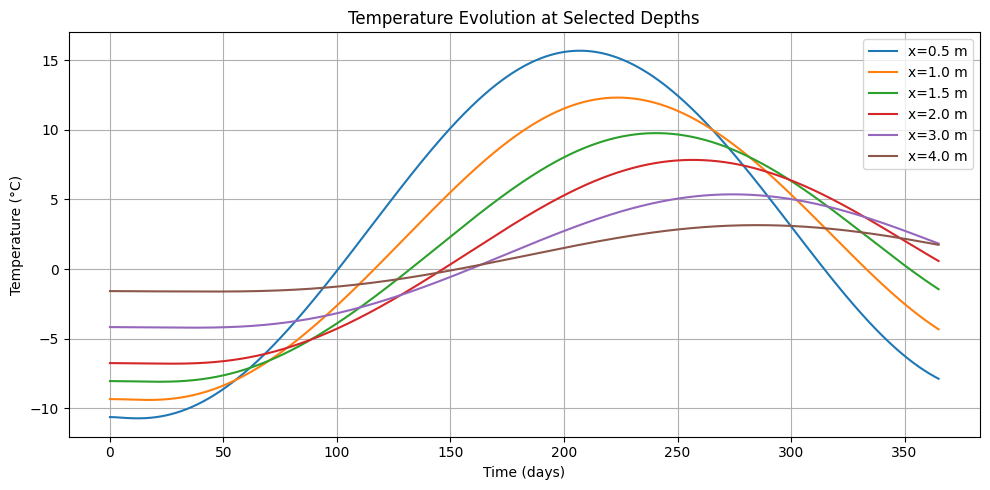

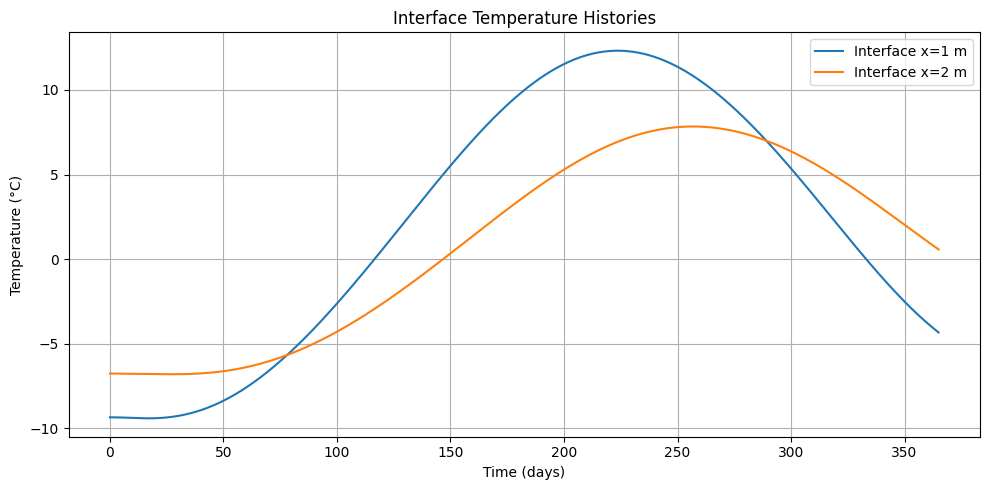

Final surface temperature = -11.926392173059488
Final bottom temperature  = 1.0
Three-layer FDM result saved to fdm_three_layer_cascade_result.npz


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import time


class FreezingSoilFDM_LogisticAHC:
    """
    1D freezing/thawing soil model
    Logistic unfrozen water content + apparent heat capacity (AHC) method
    """

    def __init__(self, params):
        # Physical parameters
        self.L = params['L']
        self.C_i = params['C_i']
        self.C_l = params['C_l']
        self.C_f = params['C_f']

        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']
        self.lambda_f = params['lambda_f']

        self.eta = params['eta']
        self.theta_r = params['theta_r']
        self.T_f = params['T_f']
        self.k = params['k']

        # Grid
        self.Nx = None
        self.Nt = None
        self.Lx = None
        self.T_total = None
        self.dx = None
        self.dt = None

        self.x = None
        self.t = None
        self.T_field = None

    def boundary_temperature(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def initial_temperature_profile(self, x):
        T_surface = self.boundary_temperature(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    def theta_unfrozen(self, T):
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + np.exp(z))

    def dtheta_dT(self, T):
        z = np.clip(-self.k * (np.asarray(T) - self.T_f), -60.0, 60.0)
        ez = np.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    def effective_heat_capacity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    @staticmethod
    def harmonic_mean(a, b, eps=1e-12):
        return 2.0 * a * b / (a + b + eps)

    def initialize(self, Nx=101, Nt=4000, Lx=5.0, T_total=365.0):
        self.Nx = Nx
        self.Nt = Nt
        self.Lx = Lx
        self.T_total = T_total

        self.dx = Lx / (Nx - 1)
        self.dt = T_total / (Nt - 1)

        self.x = np.linspace(0.0, Lx, Nx)
        self.t = np.linspace(0.0, T_total, Nt)

        self.T_field = np.zeros((Nx, Nt), dtype=float)

    def solve_implicit_custom_bc(self, top_bc_func, bottom_bc_func, init_profile, verbose=True):
        if self.T_field is None:
            raise RuntimeError("Please call initialize() first.")

        self.T_field[:, 0] = init_profile.copy()
        T_old = self.T_field[:, 0].copy()

        start = time.time()

        for n in range(1, self.Nt):
            t_new = self.t[n]

            C_app = self.apparent_heat_capacity(T_old)
            lam = self.effective_conductivity(T_old)

            A = np.zeros((self.Nx, self.Nx), dtype=float)
            b = np.zeros(self.Nx, dtype=float)

            A[0, 0] = 1.0
            b[0] = top_bc_func(t_new)

            A[-1, -1] = 1.0
            b[-1] = bottom_bc_func(t_new)

            for i in range(1, self.Nx - 1):
                lam_p = self.harmonic_mean(lam[i], lam[i + 1])
                lam_m = self.harmonic_mean(lam[i], lam[i - 1])

                coef = self.dt / (C_app[i] * self.dx ** 2)

                A[i, i - 1] = -coef * lam_m
                A[i, i] = 1.0 + coef * (lam_p + lam_m)
                A[i, i + 1] = -coef * lam_p
                b[i] = T_old[i]

            T_new = np.linalg.solve(A, b)

            if np.any(np.isnan(T_new)) or np.any(np.isinf(T_new)):
                raise RuntimeError(f"NaN/Inf detected at time step {n}")

            self.T_field[:, n] = T_new
            T_old = T_new.copy()

            if verbose and n % max(1, self.Nt // 5) == 0:
                print(f"Lx={self.Lx:.2f} m, progress: {100.0 * n / self.Nt:.1f}%")

        if verbose:
            print(f"Lx={self.Lx:.2f} m finished in {time.time() - start:.2f} s")

        return self.T_field

    def solve_original_single(self, verbose=True):
        init_profile = self.initial_temperature_profile(self.x)
        return self.solve_implicit_custom_bc(
            top_bc_func=self.boundary_temperature,
            bottom_bc_func=lambda t: 1.0,
            init_profile=init_profile,
            verbose=verbose
        )


def restricted_initial_profile_from_linear_bc(x_sub_local, x_offset, full_depth=5.0):
    """
    Initial condition built from the original global linear initial condition:
    T(x,0) = T_surface(0) + (T_bottom - T_surface(0)) * x / full_depth
    """
    T_surface0 = 4.03 + 16.11 * np.sin(2.0 * np.pi * 0.0 / 365.0 - 1.709)
    T_bottom = 1.0
    x_actual = x_sub_local + x_offset
    return T_surface0 + (T_bottom - T_surface0) * x_actual / full_depth


def run_three_layer_cascade():
    # Shared parameters
    common = {
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'theta_r': 0.10,
        'T_f': -0.3,
    }

    # Layer 1
    params1 = {
        **common,
        'C_f': 1.6,
        'lambda_f': 2.0e-6 * 8.64e4,
        'eta': 0.4,
        'k': 0.1
    }

    # Layer 2
    params2 = {
        **common,
        'C_f': 2.0,
        'lambda_f': 1.5e-6 * 8.64e4,
        'eta': 0.3,
        'k': 0.1
    }

    # Layer 3
    params3 = {
        **common,
        'C_f': 1.6,
        'lambda_f': 2.5e-6 * 8.64e4,
        'eta': 0.3,
        'k': 0.1
    }

    Nt = 4000
    T_total = 365.0

    # =====================================================
    # Step 1: 0-5 m using layer-1 parameters
    # =====================================================
    step1 = FreezingSoilFDM_LogisticAHC(params1)
    step1.initialize(Nx=101, Nt=Nt, Lx=5.0, T_total=T_total)

    init1 = step1.initial_temperature_profile(step1.x)

    T_step1 = step1.solve_implicit_custom_bc(
        top_bc_func=step1.boundary_temperature,
        bottom_bc_func=lambda tt: 1.0,
        init_profile=init1,
        verbose=True
    )

    x_full = step1.x
    t = step1.t

    idx_1m = np.argmin(np.abs(step1.x - 1.0))
    T12 = T_step1[idx_1m, :]

    # =====================================================
    # Step 2: 1-5 m using layer-2 parameters
    # =====================================================
    step2 = FreezingSoilFDM_LogisticAHC(params2)
    step2.initialize(Nx=81, Nt=Nt, Lx=4.0, T_total=T_total)

    init2 = restricted_initial_profile_from_linear_bc(
        x_sub_local=step2.x,
        x_offset=1.0,
        full_depth=5.0
    )

    T_step2 = step2.solve_implicit_custom_bc(
        top_bc_func=lambda tt: np.interp(tt, t, T12),
        bottom_bc_func=lambda tt: 1.0,
        init_profile=init2,
        verbose=True
    )

    idx_local_1m = np.argmin(np.abs(step2.x - 1.0))
    T23 = T_step2[idx_local_1m, :]

    # =====================================================
    # Step 3: 2-5 m using layer-3 parameters
    # =====================================================
    step3 = FreezingSoilFDM_LogisticAHC(params3)
    step3.initialize(Nx=61, Nt=Nt, Lx=3.0, T_total=T_total)

    init3 = restricted_initial_profile_from_linear_bc(
        x_sub_local=step3.x,
        x_offset=2.0,
        full_depth=5.0
    )

    T_step3 = step3.solve_implicit_custom_bc(
        top_bc_func=lambda tt: np.interp(tt, t, T23),
        bottom_bc_func=lambda tt: 1.0,
        init_profile=init3,
        verbose=True
    )

    # =====================================================
    # Assemble final three-layer field
    # 0-1 m from step1
    # 1-2 m from step2
    # 2-5 m from step3
    # =====================================================
    T_cascade = np.zeros_like(T_step1)

    for i, xx in enumerate(x_full):
        if xx < 1.0:
            idx = np.argmin(np.abs(step1.x - xx))
            T_cascade[i, :] = T_step1[idx, :]
        elif xx < 2.0:
            idx = np.argmin(np.abs(step2.x - (xx - 1.0)))
            T_cascade[i, :] = T_step2[idx, :]
        else:
            idx = np.argmin(np.abs(step3.x - (xx - 2.0)))
            T_cascade[i, :] = T_step3[idx, :]

    # =====================================================
    # Plot 1: full temperature field
    # =====================================================
    plt.figure(figsize=(8, 5))
    im = plt.contourf(t, x_full, T_cascade, levels=60, cmap='RdBu_r')
    plt.gca().invert_yaxis()
    plt.xlabel("Time (days)")
    plt.ylabel("Depth (m)")
    plt.title("Three-Layer Cascade Temperature Field")
    plt.colorbar(im, label="Temperature (°C)")
    plt.tight_layout()
    plt.show()

    # =====================================================
    # Plot 2: temperature profiles at selected times
    # =====================================================
    plt.figure(figsize=(8, 5))
    times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
    for tt in times_to_plot:
        idx_t = np.argmin(np.abs(t - tt))
        plt.plot(T_cascade[:, idx_t], x_full, label=f"t={int(t[idx_t])} d")
    plt.gca().invert_yaxis()
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Depth (m)")
    plt.title("Temperature Profiles")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =====================================================
    # Plot 3: temperature evolution at selected depths
    # =====================================================
    plt.figure(figsize=(10, 5))
    depths_to_plot = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
    for dd in depths_to_plot:
        idx = np.argmin(np.abs(x_full - dd))
        plt.plot(t, T_cascade[idx, :], label=f"x={x_full[idx]:.1f} m")
    plt.xlabel("Time (days)")
    plt.ylabel("Temperature (°C)")
    plt.title("Temperature Evolution at Selected Depths")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =====================================================
    # Plot 4: layer interface temperatures
    # =====================================================
    plt.figure(figsize=(10, 5))
    plt.plot(t, T12, label="Interface x=1 m")
    plt.plot(t, T23, label="Interface x=2 m")
    plt.xlabel("Time (days)")
    plt.ylabel("Temperature (°C)")
    plt.title("Interface Temperature Histories")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("Final surface temperature =", T_cascade[0, -1])
    print("Final bottom temperature  =", T_cascade[-1, -1])

    np.savez(
        "fdm_three_layer_cascade_result.npz",
        x=x_full,
        t=t,
        T_cascade=T_cascade,
        T12=T12,
        T23=T23
    )

    print("Three-layer FDM result saved to fdm_three_layer_cascade_result.npz")

    return {
        "x": x_full,
        "t": t,
        "T_cascade": T_cascade,
        "T12": T12,
        "T23": T23,
        "step1": step1,
        "step2": step2,
        "step3": step3
    }

if __name__ == "__main__":
    results = run_three_layer_cascade()

# 2. PINNs Forward Model

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time


# =========================================================
# Neural network
# =========================================================
class MLP(nn.Module):
    def __init__(self, in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_hidden - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


# =========================================================
# PINNs model for freezing/thawing soil
# =========================================================
class FreezingSoilPINN:
    """
    PINNs version corresponding to the uploaded FDM model:
        C_app(T) * dT/dt = d/dx( lambda(T) * dT/dx )

    Expanding the RHS:
        d/dx( lambda(T) * T_x )
        = lambda(T) * T_xx + d(lambda)/dT * (T_x)^2
    so the PDE residual becomes:
        C_app(T) * T_t - lambda(T) * T_xx - lambda_T(T) * (T_x)^2 = 0
    """

    def __init__(self, params, device=None):
        self.L = params['L']
        self.C_i = params['C_i']
        self.C_l = params['C_l']
        self.C_f = params['C_f']

        self.lambda_i = params['lambda_i']
        self.lambda_l = params['lambda_l']
        self.lambda_f = params['lambda_f']

        self.eta = params['eta']
        self.theta_r = params['theta_r']
        self.T_f = params['T_f']
        self.k = params['k']

        self.device = device if device is not None else (
            "cuda" if torch.cuda.is_available() else "cpu"
        )

        self.model = MLP(in_dim=2, out_dim=1, hidden_dim=64, num_hidden=5).to(self.device)

        # domain info
        self.Lx = None
        self.T_total = None

        # normalization scales
        self.x_scale = None
        self.t_scale = None

        # history
        self.loss_history = []

    # =========================================================
    # Boundary / initial conditions
    # =========================================================
    def boundary_temperature_np(self, t):
        return 4.03 + 16.11 * np.sin(2.0 * np.pi * t / 365.0 - 1.709)

    def boundary_temperature_torch(self, t):
        return 4.03 + 16.11 * torch.sin(2.0 * torch.pi * t / 365.0 - 1.709)

    def initial_temperature_profile_np(self, x):
        T_surface = self.boundary_temperature_np(0.0)
        T_bottom = 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    def initial_temperature_profile_torch(self, x):
        T_surface = self.boundary_temperature_torch(torch.zeros_like(x))
        T_bottom = torch.ones_like(x) * 1.0
        return T_surface + (T_bottom - T_surface) * x / self.Lx

    # =========================================================
    # Logistic unfrozen water model
    # =========================================================
    def theta_unfrozen(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        return self.theta_r + (self.eta - self.theta_r) / (1.0 + torch.exp(z))

    def dtheta_dT(self, T):
        z = torch.clamp(-self.k * (T - self.T_f), min=-60.0, max=60.0)
        ez = torch.exp(z)
        return (self.eta - self.theta_r) * self.k * ez / (1.0 + ez) ** 2

    # =========================================================
    # Effective properties
    # =========================================================
    def effective_heat_capacity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.C_f + theta * self.C_l + (self.eta - theta) * self.C_i

    def apparent_heat_capacity(self, T):
        return self.effective_heat_capacity(T) + self.L * self.dtheta_dT(T)

    def effective_conductivity(self, T):
        theta = self.theta_unfrozen(T)
        return (1.0 - self.eta) * self.lambda_f + theta * self.lambda_l + (self.eta - theta) * self.lambda_i

    def dlambda_dT(self, T):
        """
        lambda(T) = (1-eta) lambda_f + theta lambda_l + (eta-theta) lambda_i
                  = const + theta (lambda_l - lambda_i)
        """
        return (self.lambda_l - self.lambda_i) * self.dtheta_dT(T)

    # =========================================================
    # PINN forward
    # =========================================================
    def net_T(self, x, t):
        """
        Network input uses normalized coordinates:
            x_hat = x / Lx
            t_hat = t / T_total
        """
        x_hat = x / self.x_scale
        t_hat = t / self.t_scale
        inp = torch.cat([x_hat, t_hat], dim=1)
        return self.model(inp)

    # =========================================================
    # PDE residual
    # =========================================================
    def pde_residual(self, x, t):
        x.requires_grad_(True)
        t.requires_grad_(True)

        T = self.net_T(x, t)

        T_t = torch.autograd.grad(
            T, t,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_x = torch.autograd.grad(
            T, x,
            grad_outputs=torch.ones_like(T),
            create_graph=True,
            retain_graph=True
        )[0]

        T_xx = torch.autograd.grad(
            T_x, x,
            grad_outputs=torch.ones_like(T_x),
            create_graph=True,
            retain_graph=True
        )[0]

        C_app = self.apparent_heat_capacity(T)
        lam = self.effective_conductivity(T)
        lam_T = self.dlambda_dT(T)

        residual = C_app * T_t - lam * T_xx - lam_T * (T_x ** 2)
        return residual

    # =========================================================
    # Sampling
    # =========================================================
    def sample_collocation(self, N_f):
        x = np.random.rand(N_f, 1) * self.Lx
        t = np.random.rand(N_f, 1) * self.T_total
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device)
        )

    def sample_initial(self, N_i):
        x = np.random.rand(N_i, 1) * self.Lx
        t = np.zeros((N_i, 1))
        T0 = self.initial_temperature_profile_np(x)
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(T0, dtype=torch.float32, device=self.device)
        )

    def sample_boundary_top(self, N_b):
        x = np.zeros((N_b, 1))
        t = np.random.rand(N_b, 1) * self.T_total
        Tb = self.boundary_temperature_np(t)
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(Tb, dtype=torch.float32, device=self.device)
        )

    def sample_boundary_bottom(self, N_b):
        x = np.ones((N_b, 1)) * self.Lx
        t = np.random.rand(N_b, 1) * self.T_total
        Tb = np.ones((N_b, 1)) * 1.0
        return (
            torch.tensor(x, dtype=torch.float32, device=self.device),
            torch.tensor(t, dtype=torch.float32, device=self.device),
            torch.tensor(Tb, dtype=torch.float32, device=self.device)
        )

    # =========================================================
    # Optional supervised anchor from FDM
    # =========================================================
    def add_fdm_anchor_data(self, x_data, t_data, T_data):
        """
        Optional:
        use FDM-generated data to force PINN to reproduce FDM more closely.
        x_data, t_data, T_data must be column vectors.
        """
        self.x_data = torch.tensor(x_data, dtype=torch.float32, device=self.device)
        self.t_data = torch.tensor(t_data, dtype=torch.float32, device=self.device)
        self.T_data = torch.tensor(T_data, dtype=torch.float32, device=self.device)

    # =========================================================
    # Loss
    # =========================================================
    def loss_function(
        self,
        N_f=10000,
        N_i=2000,
        N_b=2000,
        w_pde=1.0,
        w_ic=50.0,
        w_bc=50.0,
        w_data=0.0
    ):
        # PDE
        x_f, t_f = self.sample_collocation(N_f)
        res_f = self.pde_residual(x_f, t_f)
        loss_pde = torch.mean(res_f ** 2)

        # Initial condition
        x_i, t_i, T_i_true = self.sample_initial(N_i)
        T_i_pred = self.net_T(x_i, t_i)
        loss_ic = torch.mean((T_i_pred - T_i_true) ** 2)

        # Top boundary
        x_bt, t_bt, T_bt_true = self.sample_boundary_top(N_b)
        T_bt_pred = self.net_T(x_bt, t_bt)
        loss_bc_top = torch.mean((T_bt_pred - T_bt_true) ** 2)

        # Bottom boundary
        x_bb, t_bb, T_bb_true = self.sample_boundary_bottom(N_b)
        T_bb_pred = self.net_T(x_bb, t_bb)
        loss_bc_bottom = torch.mean((T_bb_pred - T_bb_true) ** 2)

        loss_bc = loss_bc_top + loss_bc_bottom

        # Optional data loss
        loss_data = torch.tensor(0.0, device=self.device)
        if hasattr(self, "x_data") and w_data > 0.0:
            T_data_pred = self.net_T(self.x_data, self.t_data)
            loss_data = torch.mean((T_data_pred - self.T_data) ** 2)

        total_loss = (
            w_pde * loss_pde +
            w_ic * loss_ic +
            w_bc * loss_bc +
            w_data * loss_data
        )

        loss_dict = {
            "loss_total": total_loss,
            "loss_pde": loss_pde.detach().item(),
            "loss_ic": loss_ic.detach().item(),
            "loss_bc": loss_bc.detach().item(),
            "loss_data": loss_data.detach().item()
        }

        return total_loss, loss_dict

    # =========================================================
    # Train
    # =========================================================
    def train(
        self,
        Lx=5.0,
        T_total=365.0,
        epochs_adam=50000,
        lr=1e-3,
        N_f=8000,
        N_i=1000,
        N_b=1000,
        w_pde=1.0,
        w_ic=50.0,
        w_bc=50.0,
        w_data=0.0,
        print_every=500,
        use_lbfgs=True
    ):
        self.Lx = Lx
        self.T_total = T_total
        self.x_scale = Lx
        self.t_scale = T_total

        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

        start = time.time()
        print(f"Training on device: {self.device}")

        for ep in range(1, epochs_adam + 1):
            optimizer.zero_grad()

            loss, info = self.loss_function(
                N_f=N_f, N_i=N_i, N_b=N_b,
                w_pde=w_pde, w_ic=w_ic, w_bc=w_bc, w_data=w_data
            )
            loss.backward()
            optimizer.step()

            self.loss_history.append([
                ep,
                info["loss_total"].detach().item(),
                info["loss_pde"],
                info["loss_ic"],
                info["loss_bc"],
                info["loss_data"]
            ])

            if ep % print_every == 0 or ep == 1:
                print(
                    f"Epoch {ep:6d} | "
                    f"Total {info['loss_total'].detach().item():.6e} | "
                    f"PDE {info['loss_pde']:.6e} | "
                    f"IC {info['loss_ic']:.6e} | "
                    f"BC {info['loss_bc']:.6e} | "
                    f"DATA {info['loss_data']:.6e} | "
                    f"elapsed {time.time() - start:.1f}s"
                )

        if use_lbfgs:
            print("Starting L-BFGS refinement...")

            optimizer_lbfgs = torch.optim.LBFGS(
                self.model.parameters(),
                lr=1.0,
                max_iter=500,
                max_eval=500,
                tolerance_grad=1e-9,
                tolerance_change=1e-12,
                history_size=50,
                line_search_fn="strong_wolfe"
            )

            def closure():
                optimizer_lbfgs.zero_grad()
                loss, _ = self.loss_function(
                    N_f=N_f, N_i=N_i, N_b=N_b,
                    w_pde=w_pde, w_ic=w_ic, w_bc=w_bc, w_data=w_data
                )
                loss.backward()
                return loss

            optimizer_lbfgs.step(closure)

        print(f"Training completed in {time.time() - start:.1f}s")

    # =========================================================
    # Prediction
    # =========================================================
    def predict(self, x, t):
        self.model.eval()
        with torch.no_grad():
            x_ten = torch.tensor(x, dtype=torch.float32, device=self.device)
            t_ten = torch.tensor(t, dtype=torch.float32, device=self.device)
            T_pred = self.net_T(x_ten, t_ten).cpu().numpy()
        return T_pred

    def predict_field(self, Nx=101, Nt=1000):
        x = np.linspace(0.0, self.Lx, Nx)
        t = np.linspace(0.0, self.T_total, Nt)

        X, TT = np.meshgrid(x, t, indexing='ij')
        x_flat = X.reshape(-1, 1)
        t_flat = TT.reshape(-1, 1)

        T_flat = self.predict(x_flat, t_flat)
        T_field = T_flat.reshape(Nx, Nt)

        return x, t, T_field

    # =========================================================
    # Plotting
    # =========================================================
    def plot_results(self, Nx=101, Nt=1000):
        x, t, T_field = self.predict_field(Nx=Nx, Nt=Nt)

        fig, axes = plt.subplots(1, 3, figsize=(19, 5))

        im = axes[0].contourf(t, x, T_field, levels=60, cmap='RdBu_r')
        axes[0].invert_yaxis()
        axes[0].set_xlabel('Time (days)')
        axes[0].set_ylabel('Depth (m)')
        axes[0].set_title('PINN Temperature Field')
        plt.colorbar(im, ax=axes[0])

        times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
        for tt in times_to_plot:
            idx = np.argmin(np.abs(t - tt))
            axes[1].plot(T_field[:, idx], x, label=f't={t[idx]:.0f} d')
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Temperature (°C)')
        axes[1].set_ylabel('Depth (m)')
        axes[1].set_title('Temperature Profiles')
        axes[1].legend()
        axes[1].grid(True)

        depths_to_plot = [0, 0.5, 1, 2, 3, 4, 5]
        for dd in depths_to_plot:
            idx = np.argmin(np.abs(x - dd))
            axes[2].plot(t, T_field[idx, :], label=f'x={x[idx]:.2f} m')
        axes[2].set_xlabel('Time (days)')
        axes[2].set_ylabel('Temperature (°C)')
        axes[2].set_title('Temperature Evolution')
        axes[2].legend()
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

    def plot_loss(self):
        hist = np.array(self.loss_history)
        if hist.size == 0:
            print("No training history found.")
            return

        plt.figure(figsize=(7, 5))
        plt.semilogy(hist[:, 0], hist[:, 1], label='Total')
        plt.semilogy(hist[:, 0], hist[:, 2], label='PDE')
        plt.semilogy(hist[:, 0], hist[:, 3], label='IC')
        plt.semilogy(hist[:, 0], hist[:, 4], label='BC')
        plt.semilogy(hist[:, 0], hist[:, 5], label='DATA')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss History")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()





Training layer1 ...
Training on device: cuda
Epoch      1 | Total 1.837660e+02 | PDE 1.686481e-06 | IC 4.325448e+01 | BC 1.405098e+02 | DATA 0.000000e+00 | elapsed 0.0s
Epoch   5000 | Total 5.715671e-03 | PDE 1.984045e-06 | IC 4.240342e-04 | BC 3.307592e-03 | DATA 0.000000e+00 | elapsed 111.7s
Epoch  10000 | Total 1.633995e-02 | PDE 4.712220e-06 | IC 7.714714e-04 | BC 1.085626e-02 | DATA 0.000000e+00 | elapsed 211.8s
Epoch  15000 | Total 3.967473e-03 | PDE 2.309512e-06 | IC 2.856028e-04 | BC 1.372359e-03 | DATA 0.000000e+00 | elapsed 308.1s
Epoch  20000 | Total 2.673908e-03 | PDE 1.224727e-06 | IC 3.086716e-04 | BC 1.140509e-03 | DATA 0.000000e+00 | elapsed 408.8s
Epoch  25000 | Total 2.274216e-03 | PDE 8.423416e-07 | IC 2.709081e-04 | BC 1.160967e-03 | DATA 0.000000e+00 | elapsed 509.7s
Epoch  30000 | Total 2.004531e-02 | PDE 3.595863e-06 | IC 4.784413e-04 | BC 1.597101e-02 | DATA 0.000000e+00 | elapsed 616.1s
Epoch  35000 | Total 1.199215e-02 | PDE 1.001429e-05 | IC 5.089971e-04 | B

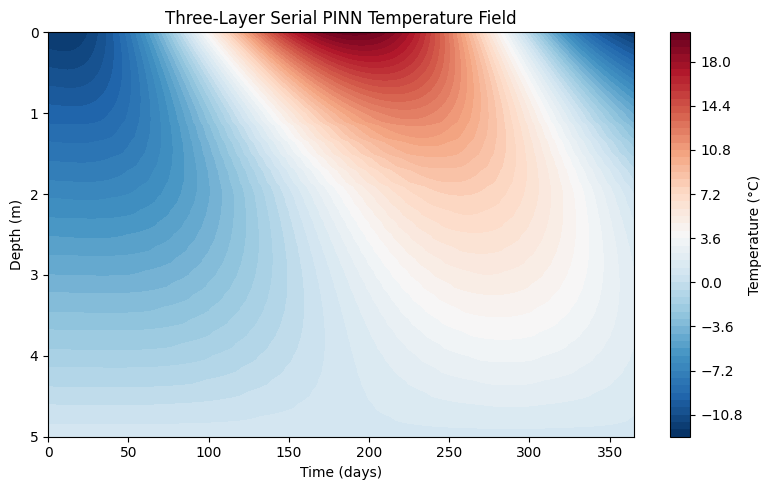

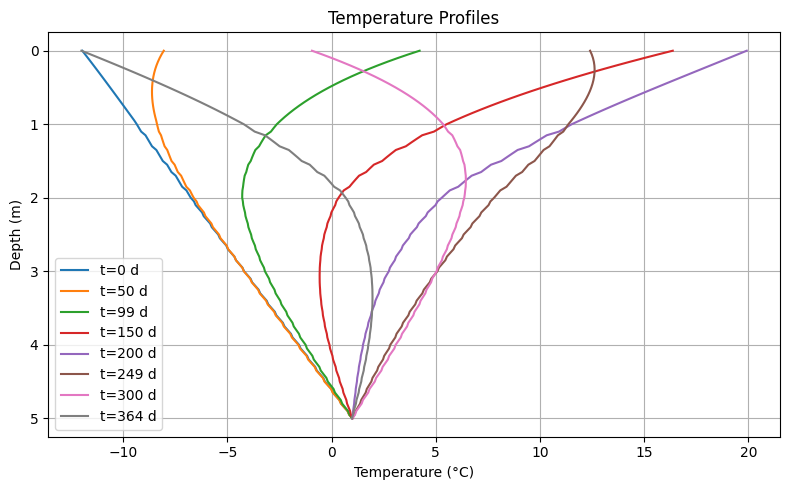

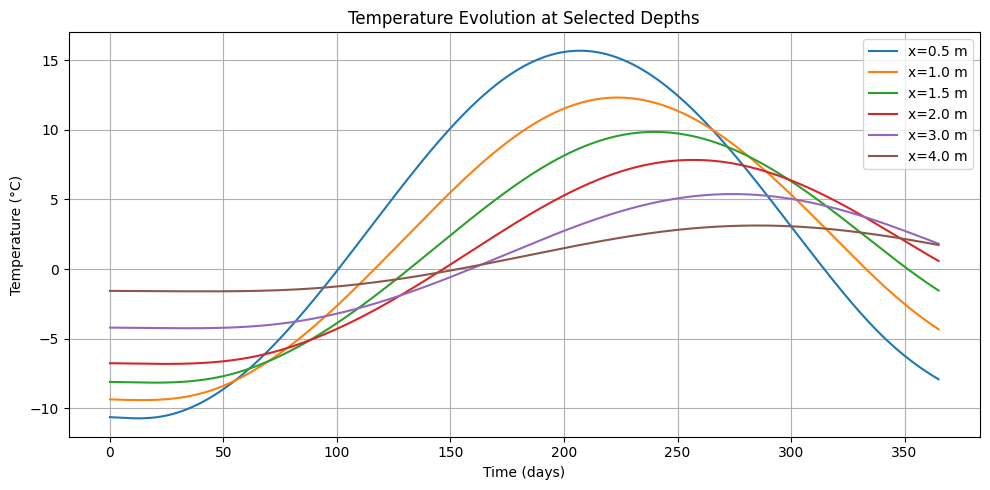

In [11]:
if __name__ == "__main__":
    import types

    # =====================================================
    # Shared parameters
    # =====================================================
    common_params = {
        'L': 334.0,
        'C_i': 1.672,
        'C_l': 4.18,
        'lambda_i': 2.210e-6 * 8.64e4,
        'lambda_l': 0.465e-6 * 8.64e4,
        'theta_r': 0.10,
        'T_f': -0.3,
        'k': 0.1
    }

    # =====================================================
    # Helpers for serial single-layer PINN
    # =====================================================
    def make_restricted_initial_sampler(x_offset):
        """
        Initial condition from the original global linear initial field,
        restricted to the subdomain [x_offset, 5].
        Local coordinate is x_local in [0, Lx_sub].
        Actual depth is x_actual = x_local + x_offset.
        """
        def sample_initial_custom(self, N_i):
            x_local = np.random.rand(N_i, 1) * self.Lx
            t = np.zeros((N_i, 1))

            T_surface0 = self.boundary_temperature_np(0.0)
            T_bottom = 1.0
            x_actual = x_local + x_offset
            T0 = T_surface0 + (T_bottom - T_surface0) * x_actual / 5.0

            return (
                torch.tensor(x_local, dtype=torch.float32, device=self.device),
                torch.tensor(t, dtype=torch.float32, device=self.device),
                torch.tensor(T0, dtype=torch.float32, device=self.device)
            )
        return sample_initial_custom

    def make_top_boundary_sampler_from_series(t_series, T_series):
        """
        Top boundary sampler using a prescribed temperature history T_bc(t).
        The top of the local domain is always x_local = 0.
        """
        t_series = np.asarray(t_series).reshape(-1)
        T_series = np.asarray(T_series).reshape(-1)

        def sample_boundary_top_custom(self, N_b):
            x = np.zeros((N_b, 1))
            t = np.random.rand(N_b, 1) * self.T_total
            Tb = np.interp(t.reshape(-1), t_series, T_series).reshape(-1, 1)
            return (
                torch.tensor(x, dtype=torch.float32, device=self.device),
                torch.tensor(t, dtype=torch.float32, device=self.device),
                torch.tensor(Tb, dtype=torch.float32, device=self.device)
            )
        return sample_boundary_top_custom

    def train_and_save_layer(
        layer_name,
        params,
        Lx,
        x_offset,
        save_name,
        model_name,
        top_bc_mode="surface",
        top_bc_t=None,
        top_bc_T=None
    ):
        """
        Train one PINN layer in the serial single-layer framework.

        top_bc_mode:
            - "surface": use original seasonal surface boundary
            - "series" : use prescribed boundary time series
        """
        print("\n" + "=" * 70)
        print(f"Training {layer_name} ...")
        print("=" * 70)

        pinn = FreezingSoilPINN(params)

        # For layer2/layer3, replace initial condition by restricted global IC
        if x_offset > 0.0:
            pinn.sample_initial = types.MethodType(
                make_restricted_initial_sampler(x_offset), pinn
            )

        # For layer2/layer3, replace top boundary by interface temperature history
        if top_bc_mode == "series":
            pinn.sample_boundary_top = types.MethodType(
                make_top_boundary_sampler_from_series(top_bc_t, top_bc_T), pinn
            )

        pinn.train(
            Lx=Lx,
            T_total=365.0,
            epochs_adam=50000,
            lr=1e-3,
            N_f=8000,
            N_i=1000,
            N_b=1000,
            w_pde=1000,
            w_ic=1.0,
            w_bc=1.0,
            w_data=0.0,
            print_every=5000,
            use_lbfgs=True
        )

        # Predict on local coordinates
        x_local, t_pinn, T_field_pinn = pinn.predict_field(Nx=101, Nt=15000)

        # Convert to actual depth coordinates for saving and later stitching
        x_actual = x_local + x_offset

        np.savez(
            save_name,
            layer_name=layer_name,
            x_local=x_local,
            x_actual=x_actual,
            t_pinn=t_pinn,
            T_field_pinn=T_field_pinn,
            x_offset=x_offset,
            Lx=Lx,
            C_f=params["C_f"],
            lambda_f=params["lambda_f"],
            eta=params["eta"],
            k=params["k"]
        )

        torch.save(pinn.model.state_dict(), model_name)

        np.savetxt(
            f"{layer_name}_loss_history.csv",
            np.array(pinn.loss_history),
            delimiter=",",
            header="epoch,total_loss,pde_loss,ic_loss,bc_loss,data_loss",
            comments=""
        )

        print(f"{layer_name} results saved to: {save_name}")
        print(f"{layer_name} model saved to: {model_name}")
        print(f"Has FDM data supervision: {hasattr(pinn, 'x_data')}")
        print(f"{layer_name} PINN T min = {np.min(T_field_pinn):.6f}")
        print(f"{layer_name} PINN T max = {np.max(T_field_pinn):.6f}")
        print(f"{layer_name} Top final T    = {T_field_pinn[0, -1]:.6f}")
        print(f"{layer_name} Bottom final T = {T_field_pinn[-1, -1]:.6f}")

        return pinn, x_local, x_actual, t_pinn, T_field_pinn

    # =====================================================
    # Layer-specific parameter sets
    # =====================================================
    params1 = {
        **common_params,
        'C_f': 1.60,
        'lambda_f': 2.000e-6 * 8.64e4,
        'eta': 0.40,
        'k': 0.1
    }

    params2 = {
        **common_params,
        'C_f': 2.00,
        'lambda_f': 1.500e-6 * 8.64e4,
        'eta': 0.30,
        'k': 0.1
    }

    params3 = {
        **common_params,
        'C_f': 1.60,
        'lambda_f': 2.500e-6 * 8.64e4,
        'eta': 0.30,
        'k': 0.1
    }

    # =====================================================
    # Step 1: layer1 on 0-5 m
    # top BC = surface seasonal temperature
    # bottom BC = 1 degC (already in class)
    # =====================================================
    pinn1, x1_local, x1_actual, t1, T1 = train_and_save_layer(
        layer_name="layer1",
        params=params1,
        Lx=5.0,
        x_offset=0.0,
        save_name="pinns_layer1_result.npz",
        model_name="pinns_layer1_model.pth",
        top_bc_mode="surface"
    )

    # Interface temperature at actual x = 1 m
    idx_1m = np.argmin(np.abs(x1_actual - 1.0))
    T12 = T1[idx_1m, :]

    np.savez(
        "layer1_interface_1m.npz",
        t_pinn=t1,
        T12=T12
    )

    # =====================================================
    # Step 2: layer2 on 1-5 m (local domain 0-4 m)
    # top BC = T12(t)
    # bottom BC = 1 degC
    # =====================================================
    pinn2, x2_local, x2_actual, t2, T2 = train_and_save_layer(
        layer_name="layer2",
        params=params2,
        Lx=4.0,
        x_offset=1.0,
        save_name="pinns_layer2_result.npz",
        model_name="pinns_layer2_model.pth",
        top_bc_mode="series",
        top_bc_t=t1,
        top_bc_T=T12
    )

    # Interface temperature at actual x = 2 m
    # In local coordinates of layer2, this is x_local = 1 m
    idx_2m = np.argmin(np.abs(x2_actual - 2.0))
    T23 = T2[idx_2m, :]

    np.savez(
        "layer2_interface_2m.npz",
        t_pinn=t2,
        T23=T23
    )

    # =====================================================
    # Step 3: layer3 on 2-5 m (local domain 0-3 m)
    # top BC = T23(t)
    # bottom BC = 1 degC
    # =====================================================
    pinn3, x3_local, x3_actual, t3, T3 = train_and_save_layer(
        layer_name="layer3",
        params=params3,
        Lx=3.0,
        x_offset=2.0,
        save_name="pinns_layer3_result.npz",
        model_name="pinns_layer3_model.pth",
        top_bc_mode="series",
        top_bc_t=t2,
        top_bc_T=T23
    )

    # =====================================================
    # Stitch final three-layer field
    # 0-1 m from layer1
    # 1-2 m from layer2
    # 2-5 m from layer3
    # =====================================================
    x_global = x1_actual.copy()
    t_global = t1.copy()
    T_global = np.zeros_like(T1)

    for i, xx in enumerate(x_global):
        if xx < 1.0:
            idx = np.argmin(np.abs(x1_actual - xx))
            T_global[i, :] = T1[idx, :]
        elif xx < 2.0:
            idx = np.argmin(np.abs(x2_actual - xx))
            T_global[i, :] = T2[idx, :]
        else:
            idx = np.argmin(np.abs(x3_actual - xx))
            T_global[i, :] = T3[idx, :]

    np.savez(
        "pinns_three_layer_stitched_result.npz",
        x_pinn=x_global,
        t_pinn=t_global,
        T_field_pinn=T_global
    )

    print("\n" + "=" * 70)
    print("Three-layer stitched result saved to: pinns_three_layer_stitched_result.npz")
    print("=" * 70)

    # Optional plots for the final stitched field
    plt.figure(figsize=(8, 5))
    im = plt.contourf(t_global, x_global, T_global, levels=60, cmap='RdBu_r')
    plt.gca().invert_yaxis()
    plt.xlabel("Time (days)")
    plt.ylabel("Depth (m)")
    plt.title("Three-Layer Serial PINN Temperature Field")
    plt.colorbar(im, label="Temperature (°C)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
    for tt in times_to_plot:
        idx_t = np.argmin(np.abs(t_global - tt))
        plt.plot(T_global[:, idx_t], x_global, label=f"t={int(t_global[idx_t])} d")
    plt.gca().invert_yaxis()
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Depth (m)")
    plt.title("Temperature Profiles")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    depths_to_plot = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
    for dd in depths_to_plot:
        idx = np.argmin(np.abs(x_global - dd))
        plt.plot(t_global, T_global[idx, :], label=f"x={x_global[idx]:.1f} m")
    plt.xlabel("Time (days)")
    plt.ylabel("Temperature (°C)")
    plt.title("Temperature Evolution at Selected Depths")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Compare 3-layer Forward Modeling Results of FDM and PINNs

===== FDM vs PINNs: Three-Layer Comparison =====
MAE      = 0.014770
RMSE     = 0.024753
Max |err|= 0.159863
Comparison result saved to fdm_vs_pinn_three_layer_comparison.npz


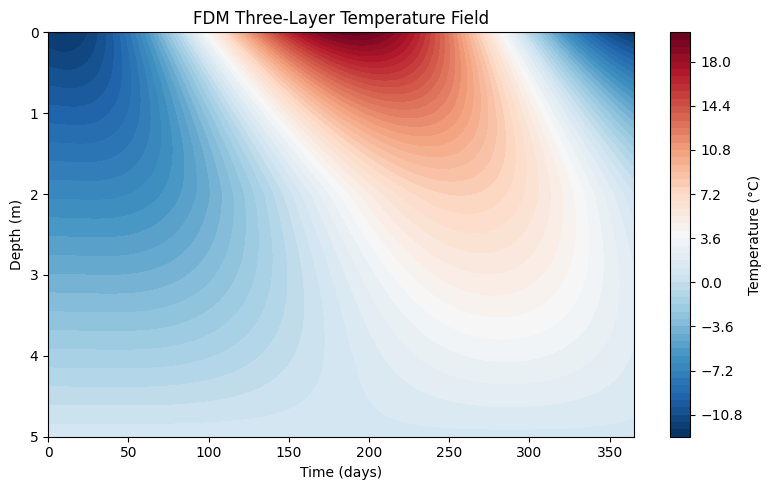

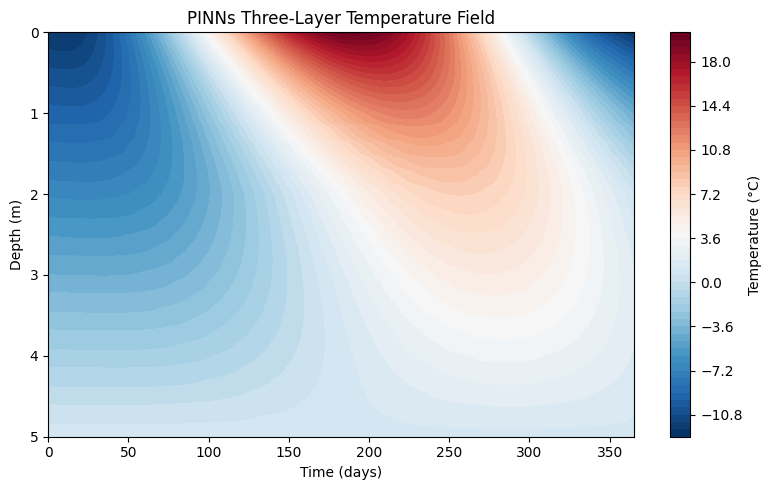

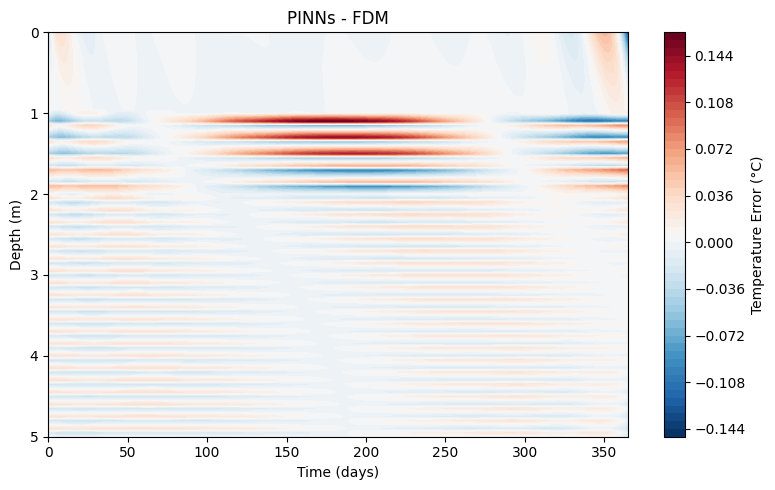

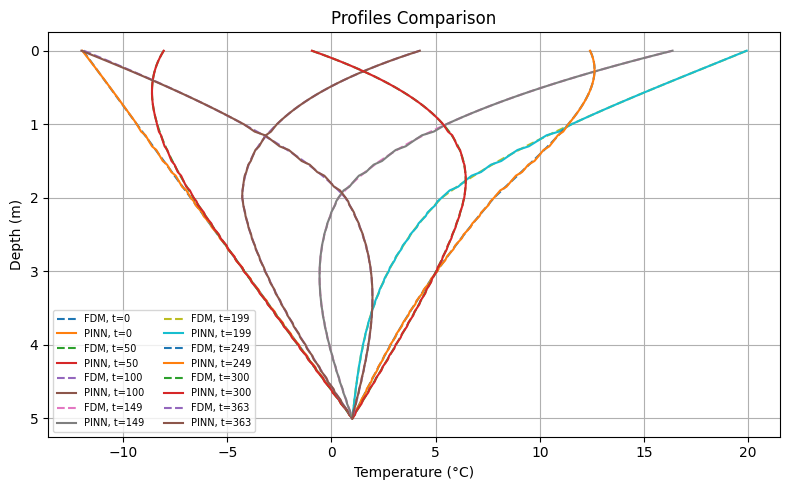

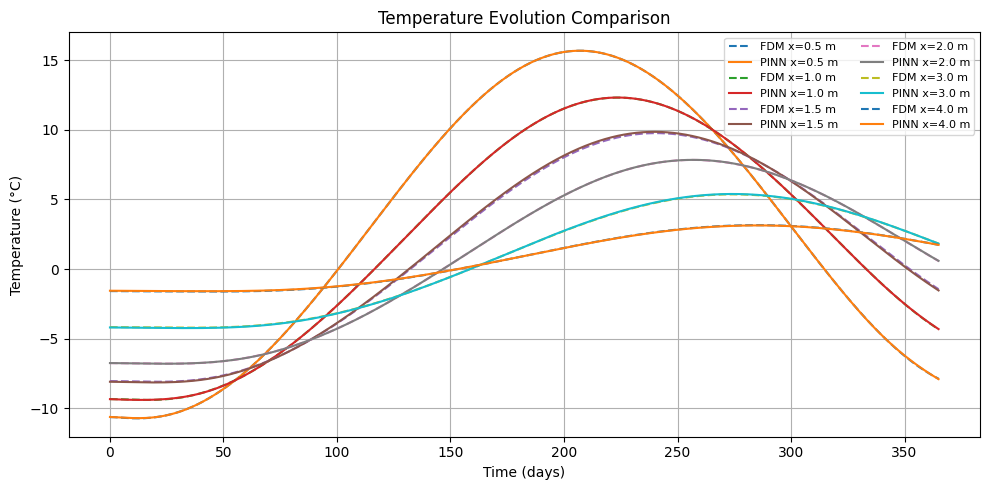

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Load FDM three-layer result
# =====================================================
fdm = np.load("fdm_three_layer_cascade_result.npz")
x_fdm = fdm["x"]
t_fdm = fdm["t"]
T_fdm = fdm["T_cascade"]

# =====================================================
# Load PINNs three-layer result
# =====================================================
pinn = np.load("pinns_three_layer_stitched_result.npz")
x_pinn = pinn["x_pinn"]
t_pinn = pinn["t_pinn"]
T_pinn = pinn["T_field_pinn"]

# =====================================================
# Check grid consistency
# If grids differ, interpolate PINNs to FDM grid
# =====================================================
same_x = (len(x_fdm) == len(x_pinn)) and np.allclose(x_fdm, x_pinn)
same_t = (len(t_fdm) == len(t_pinn)) and np.allclose(t_fdm, t_pinn)

if same_x and same_t:
    T_pinn_interp = T_pinn.copy()
else:
    # First interpolate in time, then in space
    T_temp = np.zeros((T_pinn.shape[0], len(t_fdm)))
    for i in range(T_pinn.shape[0]):
        T_temp[i, :] = np.interp(t_fdm, t_pinn, T_pinn[i, :])

    T_pinn_interp = np.zeros((len(x_fdm), len(t_fdm)))
    for j in range(len(t_fdm)):
        T_pinn_interp[:, j] = np.interp(x_fdm, x_pinn, T_temp[:, j])

# =====================================================
# Error metrics
# =====================================================
error = T_pinn_interp - T_fdm
mae = np.mean(np.abs(error))
rmse = np.sqrt(np.mean(error**2))
max_abs = np.max(np.abs(error))

print("===== FDM vs PINNs: Three-Layer Comparison =====")
print(f"MAE      = {mae:.6f}")
print(f"RMSE     = {rmse:.6f}")
print(f"Max |err|= {max_abs:.6f}")

# =====================================================
# Save comparison result
# =====================================================
np.savez(
    "fdm_vs_pinn_three_layer_comparison.npz",
    x=x_fdm,
    t=t_fdm,
    T_fdm=T_fdm,
    T_pinn=T_pinn_interp,
    error=error,
    mae=mae,
    rmse=rmse,
    max_abs=max_abs
)

print("Comparison result saved to fdm_vs_pinn_three_layer_comparison.npz")

# =====================================================
# Plot 1: FDM field
# =====================================================
plt.figure(figsize=(8, 5))
im = plt.contourf(t_fdm, x_fdm, T_fdm, levels=60, cmap="RdBu_r")
plt.gca().invert_yaxis()
plt.xlabel("Time (days)")
plt.ylabel("Depth (m)")
plt.title("FDM Three-Layer Temperature Field")
plt.colorbar(im, label="Temperature (°C)")
plt.tight_layout()
plt.show()

# =====================================================
# Plot 2: PINNs field
# =====================================================
plt.figure(figsize=(8, 5))
im = plt.contourf(t_fdm, x_fdm, T_pinn_interp, levels=60, cmap="RdBu_r")
plt.gca().invert_yaxis()
plt.xlabel("Time (days)")
plt.ylabel("Depth (m)")
plt.title("PINNs Three-Layer Temperature Field")
plt.colorbar(im, label="Temperature (°C)")
plt.tight_layout()
plt.show()

# =====================================================
# Plot 3: Error field
# =====================================================
plt.figure(figsize=(8, 5))
im = plt.contourf(t_fdm, x_fdm, error, levels=60, cmap="RdBu_r")
plt.gca().invert_yaxis()
plt.xlabel("Time (days)")
plt.ylabel("Depth (m)")
plt.title("PINNs - FDM")
plt.colorbar(im, label="Temperature Error (°C)")
plt.tight_layout()
plt.show()

# =====================================================
# Plot 4: Profiles at selected times
# =====================================================
plt.figure(figsize=(8, 5))
times_to_plot = [0, 50, 100, 150, 200, 250, 300, 364]
for tt in times_to_plot:
    idx_t = np.argmin(np.abs(t_fdm - tt))
    plt.plot(T_fdm[:, idx_t], x_fdm, '--', label=f"FDM, t={int(t_fdm[idx_t])}")
    plt.plot(T_pinn_interp[:, idx_t], x_fdm, '-', label=f"PINN, t={int(t_fdm[idx_t])}")
plt.gca().invert_yaxis()
plt.xlabel("Temperature (°C)")
plt.ylabel("Depth (m)")
plt.title("Profiles Comparison")
plt.grid(True)
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

# =====================================================
# Plot 5: Time evolution at selected depths
# =====================================================
plt.figure(figsize=(10, 5))
depths_to_plot = [0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
for dd in depths_to_plot:
    idx = np.argmin(np.abs(x_fdm - dd))
    plt.plot(t_fdm, T_fdm[idx, :], '--', label=f"FDM x={x_fdm[idx]:.1f} m")
    plt.plot(t_fdm, T_pinn_interp[idx, :], '-', label=f"PINN x={x_fdm[idx]:.1f} m")
plt.xlabel("Time (days)")
plt.ylabel("Temperature (°C)")
plt.title("Temperature Evolution Comparison")
plt.grid(True)
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# 3 PINNs for Inversion